# Analysis and Visualisation

### Installing libraries and importing modules

In [5]:
!pip install pandas

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.ticker import FuncFormatter

### ONS - General Health 2011 / 2021

General health by age, sex and deprivation, England and Wales: Census 2021
Insights into general health in England and Wales in 2021, broken down by age and sex and presented at country, regional and local authority level.

#### Reading the cleaned data

In [3]:
census_health_sex = pd.read_csv("../data/clean/cleaned_census_health_sex.csv")
census_health_sex.head()

,year,country,health_status,sex,count,population,age_standardised_percentage,lower_95pct_confidence_interval,upper_95pct_confidence_interval
0,2021,England,Very good,Female,13653975,28833720,47.1,47.1,47.2
1,2021,England,Very good,Male,13736855,27656330,47.9,47.9,48.0
2,2021,England,Good,Female,9769630,28833720,34.2,34.1,34.2
3,2021,England,Good,Male,9271115,27656330,34.2,34.1,34.2
4,2021,England,Fair,Female,3807185,28833720,13.2,13.2,13.2


#### Health status by sex (2021)- How do men and women differ in self-reported health today?

In [4]:
# Filtering to 2021 DF
health_2021 = census_health_sex[census_health_sex["year"] == 2021]

In [5]:
# Prepping for visualisation

pivot_2021 = health_2021.pivot_table(
    index="health_status",
    columns="sex",
    values="age_standardised_percentage"
)

pivot_2021

sex,Female,Male
health_status,,
Bad,4.85,4.40
Fair,13.75,13.30
Good,33.35,33.40
Very bad,1.40,1.40
Very good,46.60,47.55


#### Self-Rated Health by sex

<Figure size 1000x600 with 0 Axes>

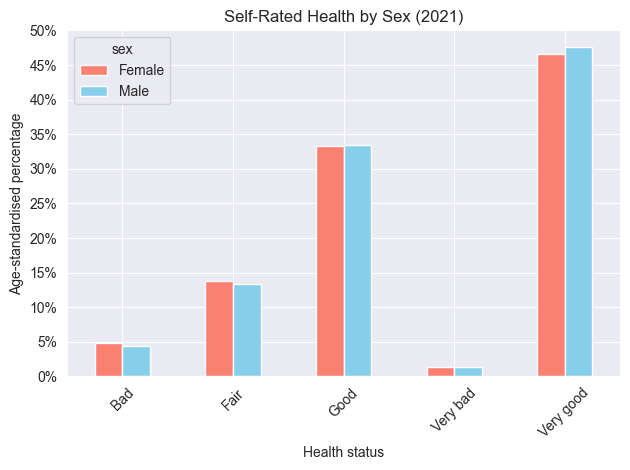

In [6]:
plt.figure(figsize=(10,6))

# Defining colours
my_colours = ['salmon', 'skyblue']

# Passing the colour argument
ax = pivot_2021.plot(kind="bar", color=my_colours)

# The rest of your styling remains exactly the same
ax.set_title("Self-Rated Health by Sex (2021)")
ax.set_xlabel("Health status")
ax.set_ylabel("Age-standardised percentage")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")

# Add more tick marks for readability
ax.set_yticks(range(0, 55, 5))  # 0%, 5%, 10%, ..., 50%

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Plot summary:**

- Most men and women report their health as either “Good” or “Very good”
- Men are slightly more likely to report “Very good” health than women
- Women are slightly more represented in the “Fair” and “Bad” categories
- The overall pattern is very similar between sexes, with only small differences across categories
- “Very bad” health is a very small proportion for both groups

**Interpretation (safe and accurate)**

- The data suggests subtle but measurable differences in how men and women rate their health
- These figures reflect population-level health patterns, not healthcare usage or cost
- The chart provides context, which may help explain differences later seen in NHS activity or spending data.

#### Change in 'Very Good' Self-Rated Health (2011-2021)

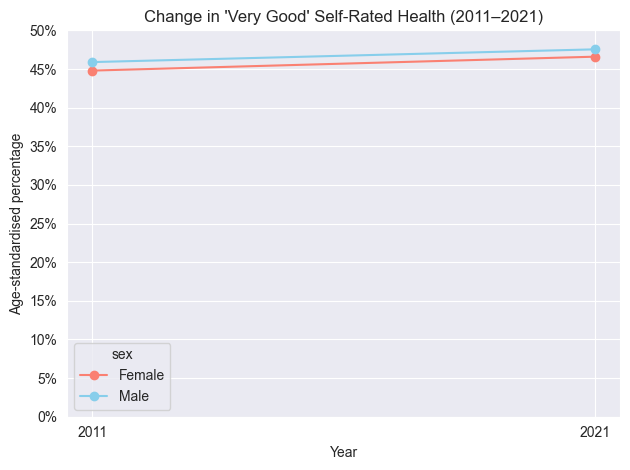

In [7]:
# Filtering to just the "Very good" category
very_good = census_health_sex[census_health_sex["health_status"] == "Very good"]

# Creating a pivot table
pivot_vg = very_good.pivot_table(
    index="year",
    columns="sex",
    values="age_standardised_percentage"
)

my_colours = ['salmon', 'skyblue']

# Plotting as a line chart with the specific colours
ax = pivot_vg.plot(marker="o", color=my_colours)

# Titles and labels
ax.set_title("Change in 'Very Good' Self-Rated Health (2011–2021)")
ax.set_xlabel("Year")
ax.set_ylabel("Age-standardised percentage")

# Showing years clearly on x-axis
plt.xticks([2011, 2021])

# Showing more y-axis detail (every 5%)
ax.set_yticks(range(0, 55, 5))
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")

# Cleaning layout
plt.tight_layout()
plt.show()

**Plot summary:**

- Both men and women report a small increase in “Very good” health over time
- Men consistently report slightly higher levels than women
- The difference between sexes has remained narrow and stable
- This indicates a broadly similar trend for both groups across the decade

#### Overall Health Profile by Sex (2021)

<Figure size 1000x600 with 0 Axes>

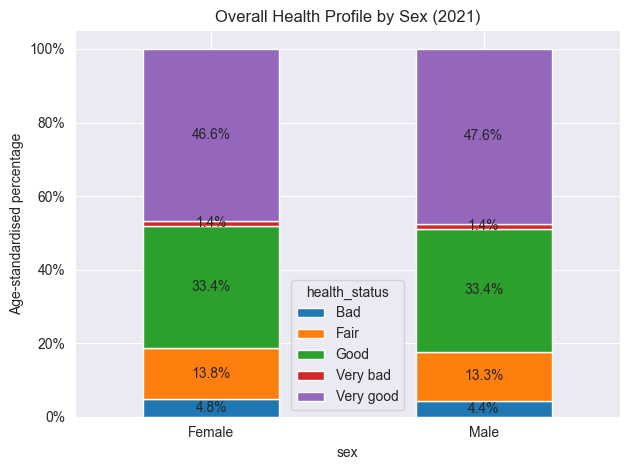

In [8]:
# Filtering to 2021 data
health_2021 = census_health_sex[census_health_sex["year"] == 2021]

# Pivoting for stacked bar
stacked = health_2021.pivot_table(
    index="sex",
    columns="health_status",
    values="age_standardised_percentage"
)

# Plotting
plt.figure(figsize=(10,6))
ax = stacked.plot(kind="bar", stacked=True)

# Axis formatting
ax.set_title("Overall Health Profile by Sex (2021)")
ax.set_ylabel("Age-standardised percentage")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")
plt.xticks(rotation=0)

# Adding % labels to each segment
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.tight_layout()
plt.show()

**Plot summary:**

- Both sexes are heavily concentrated in “Very good” and “Good” health categories
- Overall shape of the distribution is very similar for men and women
- Men show a slightly larger share in the “Very good” category
- Women show slightly higher representation in “Fair” and “Bad” categories
- The differences are present but not large in scale
- The stacked distribution shows that health outcomes are broadly similar between men and women. Minor differences exist, but there is no evidence of a major structural gap based on this dataset alone.

#### 10-Year trend: Percentage Reporting Poor Health (England)

In [9]:
df = census_health_sex

# Filtering to England (that's what we decided to focus on per the proposal) & grouping all bad results

df_england = df[df['country'] == 'England'].copy()
df_bad = df_england[df_england['health_status'].isin(['Bad', 'Very bad'])].copy()


# Calculating the %ges

trend_data = df_bad.groupby(['year', 'sex'])['age_standardised_percentage'].sum().reset_index()
pivot_trend = trend_data.pivot(index='year', columns='sex', values='age_standardised_percentage')

display(pivot_trend)

sex,Female,Male
year,,
2011,5.9,6.0
2021,5.5,5.1


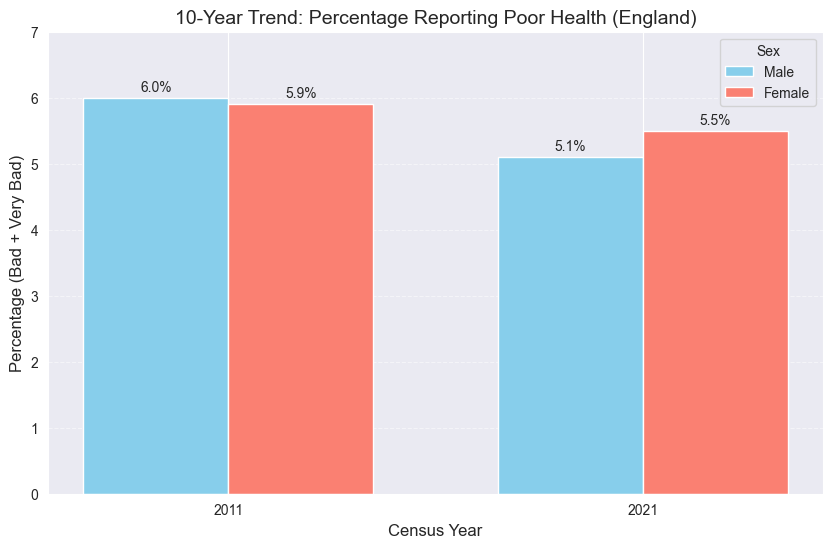

In [10]:
# Plotting

plt.figure(figsize=(10, 6))

years = pivot_trend.index  # [2011, 2021]
x_pos = np.arange(len(years))
width = 0.35


# Plotting Bars
plt.bar(x_pos - width/2, pivot_trend['Male'], width, label='Male', color='skyblue')
plt.bar(x_pos + width/2, pivot_trend['Female'], width, label='Female', color='salmon')


# Labels and Title
plt.title('10-Year Trend: Percentage Reporting Poor Health (England)', fontsize=14)
plt.ylabel('Percentage (Bad + Very Bad)', fontsize=12)
plt.xlabel('Census Year', fontsize=12)
plt.xticks(x_pos, years) # X-axis shows 2011 and 2021
plt.ylim(0, pivot_trend.max().max() + 1) # adding space


# Adding the numbers on top of the bars
for i, year in enumerate(years):
    # Male Label
    m_val = pivot_trend.loc[year, 'Male']
    plt.text(i - width/2, m_val + 0.1, f'{m_val:.1f}%', ha='center') # position of the text

    # Female Label
    f_val = pivot_trend.loc[year, 'Female']
    plt.text(i + width/2, f_val + 0.1, f'{f_val:.1f}%', ha='center')

plt.legend(title='Sex')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

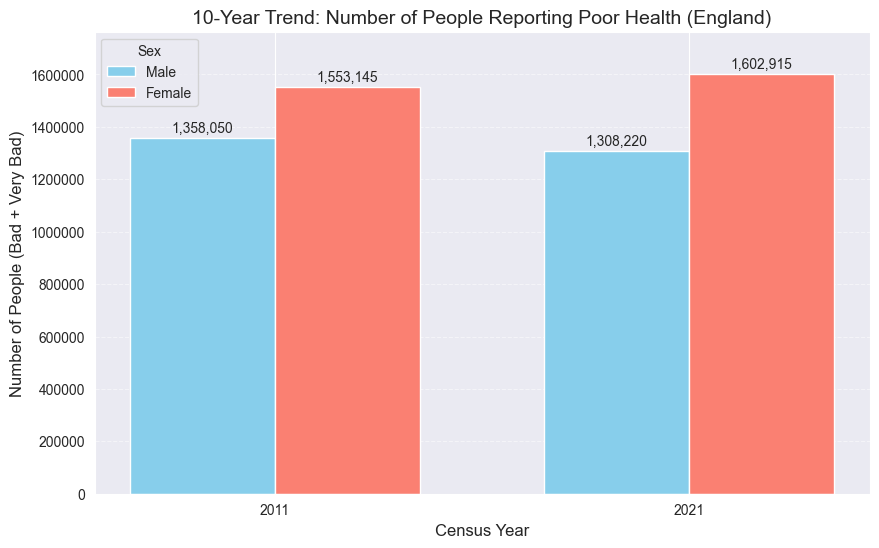

In [11]:
# same as above, but with numbers instead of percentages:


trend_data_counts = df_bad.groupby(['year', 'sex'])['count'].sum().reset_index()
pivot_trend_counts = trend_data_counts.pivot(index='year', columns='sex', values='count')

# display(pivot_trend_counts)


plt.figure(figsize=(10, 6))

years = pivot_trend_counts.index
x_pos = np.arange(len(years))
width = 0.35

# Plot Bars
plt.bar(x_pos - width/2, pivot_trend_counts['Male'], width, label='Male', color='skyblue')
plt.bar(x_pos + width/2, pivot_trend_counts['Female'], width, label='Female', color='salmon')

# Labels and Title
plt.title('10-Year Trend: Number of People Reporting Poor Health (England)', fontsize=14)
plt.ylabel('Number of People (Bad + Very Bad)', fontsize=12)
plt.xlabel('Census Year', fontsize=12)
plt.xticks(x_pos, years)
plt.ylim(0, pivot_trend_counts.max().max() * 1.1) # add 10% padding to the top
plt.ticklabel_format(style='plain', axis='y')

# Text Labels
for i, year in enumerate(years):
    # Male Label
    m_val = pivot_trend_counts.loc[year, 'Male']
    # Format as a whole number with a comma separator
    plt.text(i - width/2, m_val + 20000, f'{m_val:,.0f}', ha='center')

    # Female Label
    f_val = pivot_trend_counts.loc[year, 'Female']
    plt.text(i + width/2, f_val + 20000, f'{f_val:,.0f}', ha='center')

plt.legend(title='Sex')
plt.grid(axis='y', linestyle='--', alpha=0.5)

**Plots summary:**

- The percentage of both men and women reporting poor health decreased between 2011 and 2021, indicating an overall improvement in self-reported health in England
- Men saw a larger drop in the rate of poor health, decreasing by 0.9 percentage points (from 6.0% to 5.1%). Women's rate also improved, but by a smaller margin of 0.4 percentage points (from 5.9% to 5.5%)
- The data shows a flip in which sex reports a higher rate of poor health. In 2011, a slightly higher percentage of men reported poor health than women. By 2021, this reversed, with a slightly higher percentage of women reporting poor health
- Despite the percentage decrease, the absolute number of women reporting poor health actually rose slightly between 2011 and 2021 (from 1.55M to 1.60M). In contrast, the absolute number of men reporting poor health fell (from 1.36M to 1.31M)
- While England's overall health has improved on a percentage basis for both sexes over the decade, the gains were more significant for men. The rising absolute number of women with poor health, despite a falling percentage, likely points to demographic factors like population growth and underscores that the total healthcare burden for this group may still be increasing



## Visualising NHS Demographics- Male vs Female by Ethnic Group

In [12]:
# Make plots bigger as default
plt.rcParams['figure.figsize'] = (10,6)

In [13]:
# Path to the clean demographics datasets
csv_path = '../data/clean/demographics_ethnic_sex_clean.csv'

demog_sex_df = pd.read_csv(csv_path)

demog_sex_df.head()

,Ethnic_Code,Ethnic_Description,Total_FCE,Total_FAE,Male_FCE,Female_FCE
0,A,British (White),14647984,11765955,6605131,7955166
1,B,Irish (White),143887,110968,65525,77279
2,C,Any other White background,963874,816817,391041,563634
3,D,White and Black Caribbean (Mixed),70872,62743,25736,44619
4,E,White and Black African (Mixed),38271,33925,14997,22887


In [14]:
# Checking columns and data types

demog_sex_df.dtypes

Ethnic_Code           object
Ethnic_Description    object
Total_FCE              int64
Total_FAE              int64
Male_FCE               int64
Female_FCE             int64
dtype: object

1: Overall hospital usage by sex

This chart shows the total number of Finished Consultant Episodes (FCSs) for men and women across all ethnic groups combined

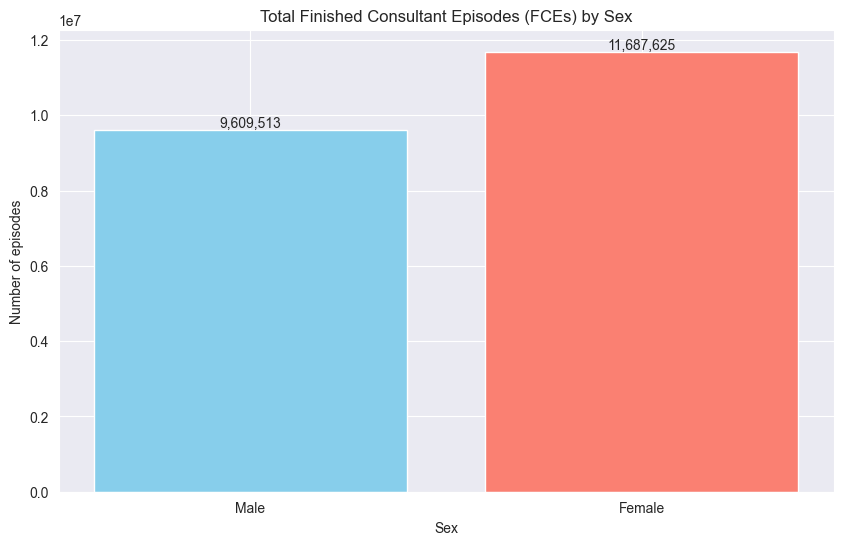

In [15]:
# Sum of male and female FCEs across all ethnic groups

total_male_fce = demog_sex_df['Male_FCE'].sum()
total_female_fce = demog_sex_df['Female_FCE'].sum()

# Creating bar chart
sex_labels = ['Male', 'Female']
totals = [total_male_fce, total_female_fce]

plt.figure()
plt.bar(sex_labels, totals, color=['skyblue', 'salmon'])
plt.title('Total Finished Consultant Episodes (FCEs) by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of episodes')

# Show values on top of bars for clarity
for i, value in enumerate(totals):
    plt.text(i, value, f'{value:,}', ha='center', va='bottom')

plt.show()

2: Male vs Female by ethnic group

This chart shows, for the 10 ethnic groups with the highest number of hospital episodes, how many were FCEs were for men vs women

<function matplotlib.pyplot.show(close=None, block=None)>

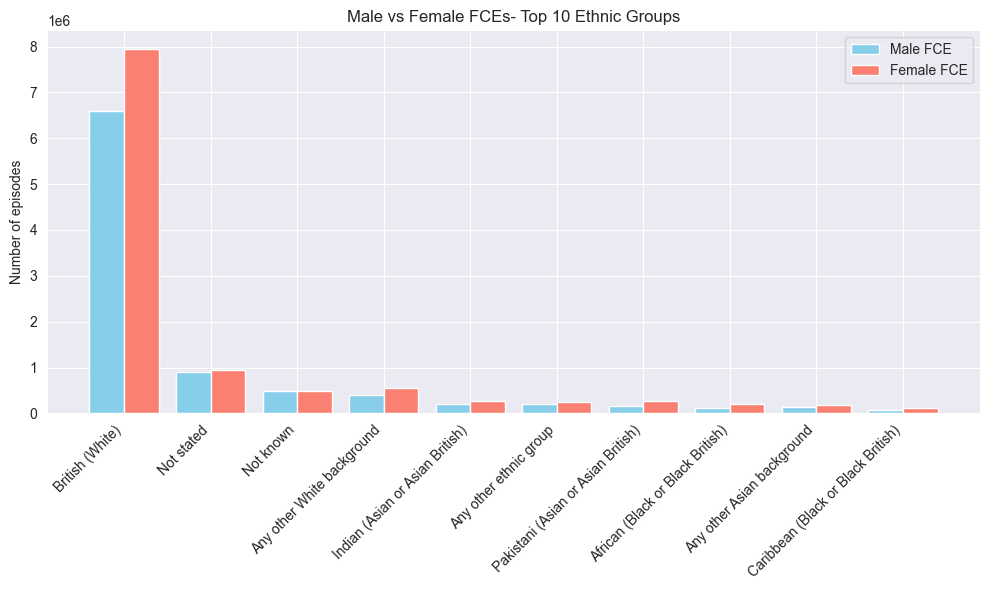

In [16]:
# Sorting by FCE and taking the top 10 ethnic groups
top10 = demog_sex_df.sort_values('Total_FCE', ascending=False).head(10)

x = range(len(top10))

width = 0.4

plt.figure()

# Moving the bars to stop them overlapping
plt.bar([i-width/2 for i in x], top10['Male_FCE'], width=width, label='Male FCE',color='skyblue')
plt.bar([i+width/2 for i in x], top10['Female_FCE'], width=width, label='Female FCE', color='salmon')

# Axis labels
plt.xticks(ticks=x, labels=top10['Ethnic_Description'], rotation=45, ha='right')

plt.ylabel('Number of episodes')
plt.title('Male vs Female FCEs- Top 10 Ethnic Groups')
plt.legend()

plt.tight_layout()
plt.show

3: Female share by ethnic group

This graph shows what percentage of FCEs were for women, by ethnic group

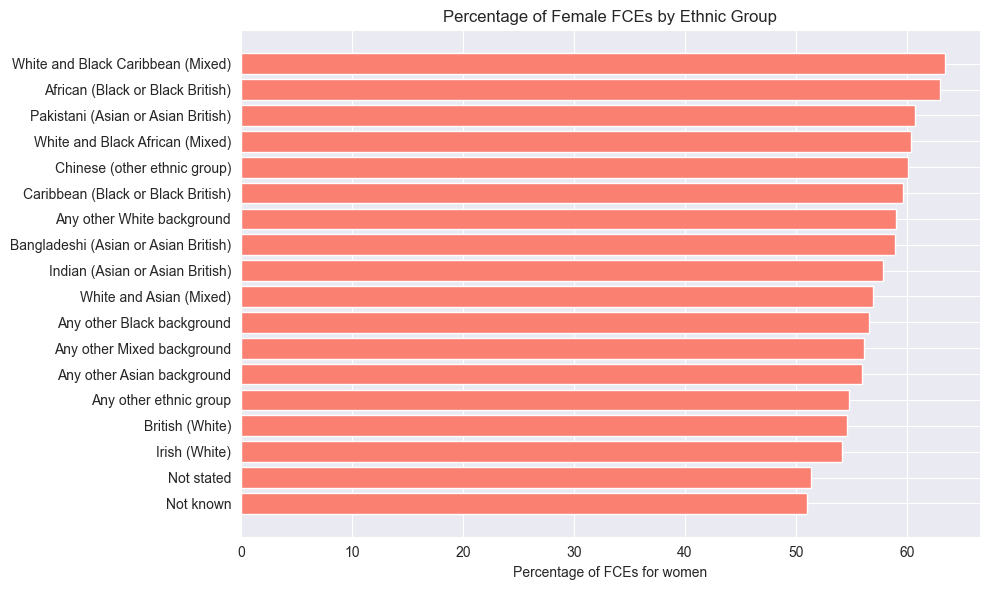

In [17]:
demog_pct = demog_sex_df.copy()

# Total male and female FCE per group
demog_pct['Total_MF_FCE'] = demog_pct['Male_FCE'] + demog_pct['Female_FCE']

# Calculate percentage of female episodes
demog_pct['Female_pct'] = demog_pct.apply(
    lambda row: (row['Female_FCE'] / row['Total_MF_FCE']) * 100 if row['Total_MF_FCE'] > 0 else None,
    axis=1
)

demog_pct_sorted = demog_pct.sort_values('Female_pct', ascending=False)

plt.figure()
plt.barh(demog_pct_sorted['Ethnic_Description'], demog_pct_sorted['Female_pct'], color='salmon')
plt.xlabel('Percentage of FCEs for women')
plt.title('Percentage of Female FCEs by Ethnic Group')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Our project asks the question ‘Is healthcare more expensive for cisgender men vs women, and how so?’

The cleaned demographics dataset and corresponding visuals provide important context for this question. This data does not show costs directly but does show how often men and women use inpatient hospital services broken down by ethnic group.

The first bar chart (total FCEs by sex) shows that women have a higher number of FCEs than men overall which suggests that before we take costs into consideration, women may account for a larger share of inpatient activity.

The second bar chart shows that this pattern is repeated across most ethnic categories. It is important to take into account how frequently men and women use hospital care when comparing healthcare costs.

The last bar chart shows what proportion of episodes are by women for each ethnic group. This helps identify ethnic groups where the gender imbalance in usage is strong. We can use this information to explore whether higher spending by women is mainly due to higher usage, higher cost per episode or a combination of both.

## Hospital Admitted Patient Care - Diagnosis

This dataset reports on Admitted Patient Care activity in England for the financial year 2023-24. The records refer to 'Finished Consultant Episodes', and each episode relates to a period of care for a patient under a single consultant at a single hospital.

In [5]:
# Hospital admitted patient care 2023-24 - Primary Diagnosis Summary table
diagnosis_summary_df = pd.read_csv('../data/clean/diagnosis_summary_clean.csv')

# Hospital admitted patient care 2023-24 - Primary Diagnosis 3 Character code table
diagnosis_3_char_df = pd.read_csv('../data/clean/diagnosis_3_char_clean.csv')

In [19]:
# sampling the data and looking at data types and shape

print(diagnosis_summary_df.sample(5))
print(diagnosis_summary_df.info())

print(diagnosis_3_char_df.sample(5))
print(diagnosis_3_char_df.info())

        code                                        description     sex  \
221  A65-A69                        Other spirochaetal diseases  Female   
107  J90-J94                           Other diseases of pleura    Male   
322  J85-J86  Suppurative and necrotic conditions of lower r...  Female   
346  M60-M79                              Soft tissue disorders  Female   
191  S50-S59                    Injuries to the elbow & forearm    Male   

     diagnosis_count                                           category  
221              290  Certain infectious and parasitic diseases (A00...  
107            38392       Diseases of the respiratory system (J00–J99)  
322             4252       Diseases of the respiratory system (J00–J99)  
346           137872  Diseases of the musculoskeletal system and con...  
191            29079  Injury, poisoning and certain other consequenc...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 5 columns):
 

Text(0, 0.5, 'Diagnosis Count')

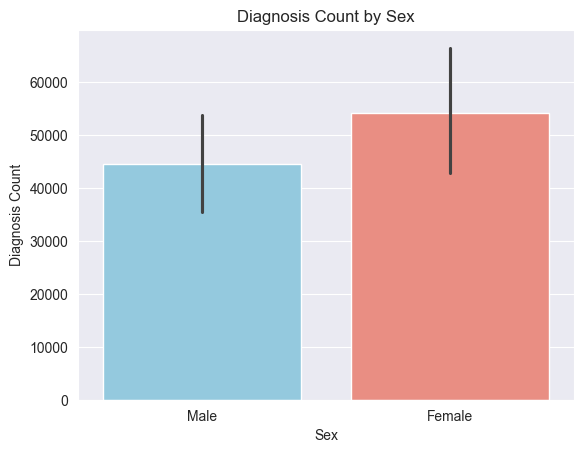

In [6]:
palette = {"Female": "salmon", "Male": "skyblue"}

sns.barplot(
    data=diagnosis_summary_df, x="sex", y="diagnosis_count", hue="sex", palette=palette
)
plt.title('Diagnosis Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Diagnosis Count')

In [7]:
# making wide version of dataframe to add totals column
diagnosis_summary_wide = diagnosis_summary_df.pivot(index='description', columns='sex', values='diagnosis_count')
diagnosis_summary_wide['total'] = diagnosis_summary_wide.sum(axis=1)

diagnosis_summary_wide.head()

sex,Female,Male,total
description,,,
Abnormal findings on diagnostic imaging/function studies,31251,28206,59457
"Abnormal findings on examination of blood, without diagnosis",15691,24007,39698
"Abnormal findings on examination of other body fluids, substances and tissues, without diagnosis",2350,707,3057
"Abnormal findings on examination of urine, without diagnosis",734,743,1477
Acute rheumatic fever,73,52,125


In [8]:
top_10_diagnoses = diagnosis_summary_wide.sort_values(by=['total'], ascending=False).head(10)
display(top_10_diagnoses)

sex,Female,Male,total
description,,,
Disorders of lens (including cataracts),437026,308994,746020
Other diseases of intestines,380042,351026,731068
General symptoms & signs,373440,318562,692002
Influenza & pneumonia,313724,310456,624180
Other forms of heart disease,253225,328884,582109
Symptoms & signs inv. the digestive system & abdomen,368544,197018,565562
Arthropathies,333696,227662,561358
Health services in circumstances related to reproduction,316606,184215,500821
"Diseases of oesophagus, stomach & duodenum",254757,244242,498999


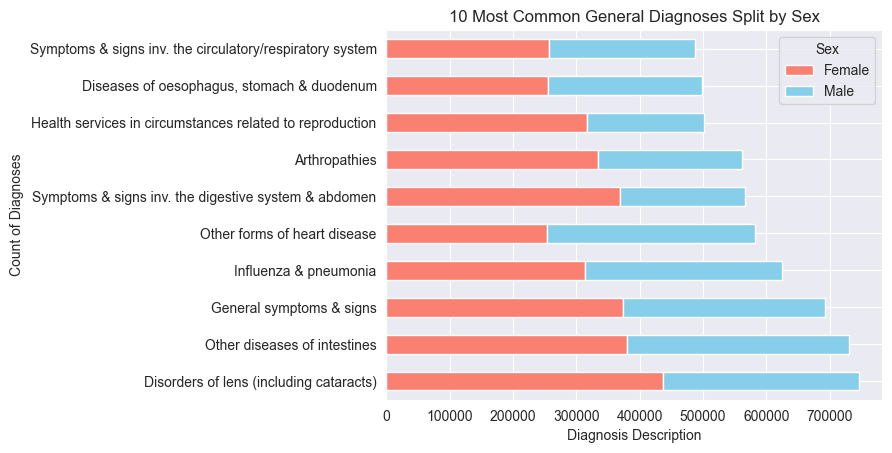

In [9]:
diag_10_subset = top_10_diagnoses[["Female", "Male"]]

diag_10_subset.plot(kind='barh', stacked=True, color=['salmon', 'skyblue'])
plt.title('10 Most Common General Diagnoses Split by Sex')
plt.xlabel('Diagnosis Description')
plt.ylabel('Count of Diagnoses')

plt.legend(title='Sex')

In [10]:
top_10_diagnoses['male_proportion'] = top_10_diagnoses['Male'] / top_10_diagnoses['total']
top_10_diagnoses['female_proportion'] = top_10_diagnoses['Female'] / top_10_diagnoses['total']

display(top_10_diagnoses)

sex,Female,Male,total,male_proportion,female_proportion
description,,,,,
Disorders of lens (including cataracts),437026,308994,746020,0.414190,0.585810
Other diseases of intestines,380042,351026,731068,0.480155,0.519845
General symptoms & signs,373440,318562,692002,0.460348,0.539652
Influenza & pneumonia,313724,310456,624180,0.497382,0.502618
Other forms of heart disease,253225,328884,582109,0.564987,0.435013
Symptoms & signs inv. the digestive system & abdomen,368544,197018,565562,0.348358,0.651642
Arthropathies,333696,227662,561358,0.405556,0.594444
Health services in circumstances related to reproduction,316606,184215,500821,0.367826,0.632174
"Diseases of oesophagus, stomach & duodenum",254757,244242,498999,0.489464,0.510536


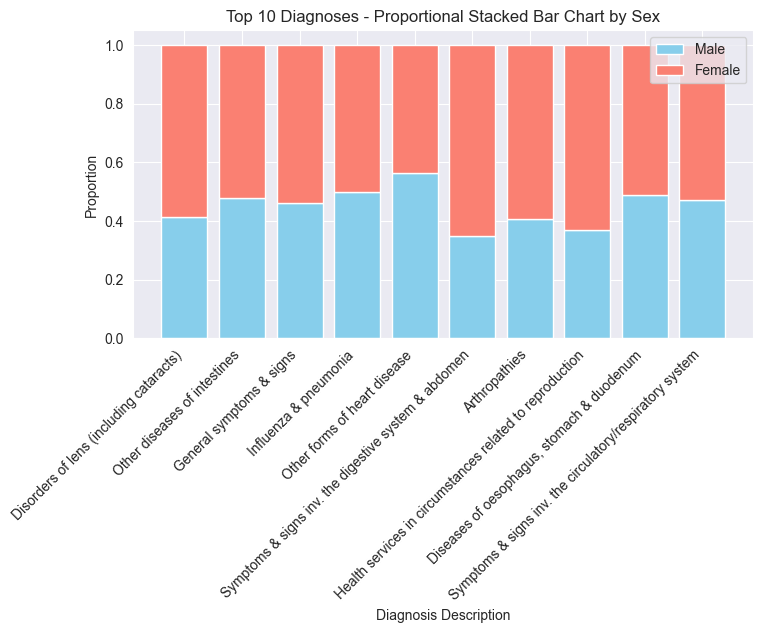

In [13]:
plt.figure(figsize=(8, 4))
plt.bar(top_10_diagnoses.index, top_10_diagnoses['male_proportion'], label='Male', color='skyblue')
plt.bar(top_10_diagnoses.index, top_10_diagnoses['female_proportion'], label='Female', bottom=top_10_diagnoses['male_proportion'], color='salmon')
plt.xlabel('Diagnosis Description')
plt.ylabel('Proportion')
plt.title('Top 10 Diagnoses - Proportional Stacked Bar Chart by Sex')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

The plot above shows the 10 most common general diagnoses in hospital admitted patient care in the 2023-24 period, based on the summary dataset which groups types of diagnosis. This takes into account the total number of diagnoses including men and women.

Text(0, 0.5, 'Category')

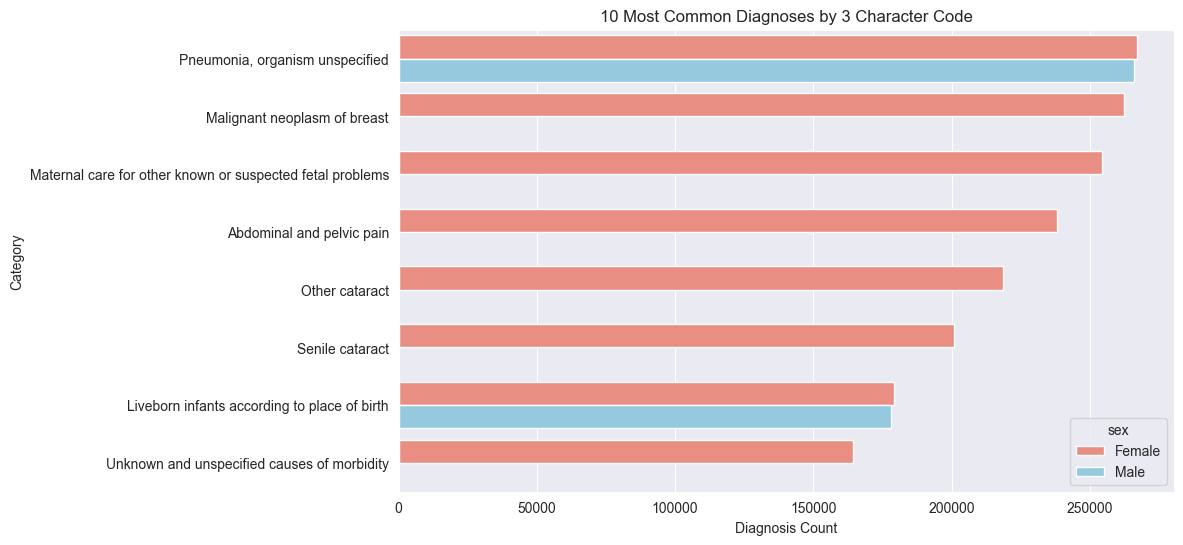

In [79]:
top_10_3_char = diagnosis_3_char_df.sort_values(by='diagnosis_count', ascending=False).head(10)
top_10_3_char_plot = sns.barplot(top_10_3_char, x='diagnosis_count', y='description', hue='sex', palette=palette)
plt.title('10 Most Common Diagnoses by 3 Character Code')
plt.xlabel('Diagnosis Count')
plt.ylabel('Category')

This plot shows the 10 most frequently diagnosed conditions in the dataset. Neoplasms of the breast and maternal care are female-specific, however the female patients receive more diagnoses of non-sex-specific conditions.

Across both plots, more diagnoses were given to women than men in the majority of the top 10.

The only diagnosis area in which men had a significantly greater diagnosis count was heart disease.

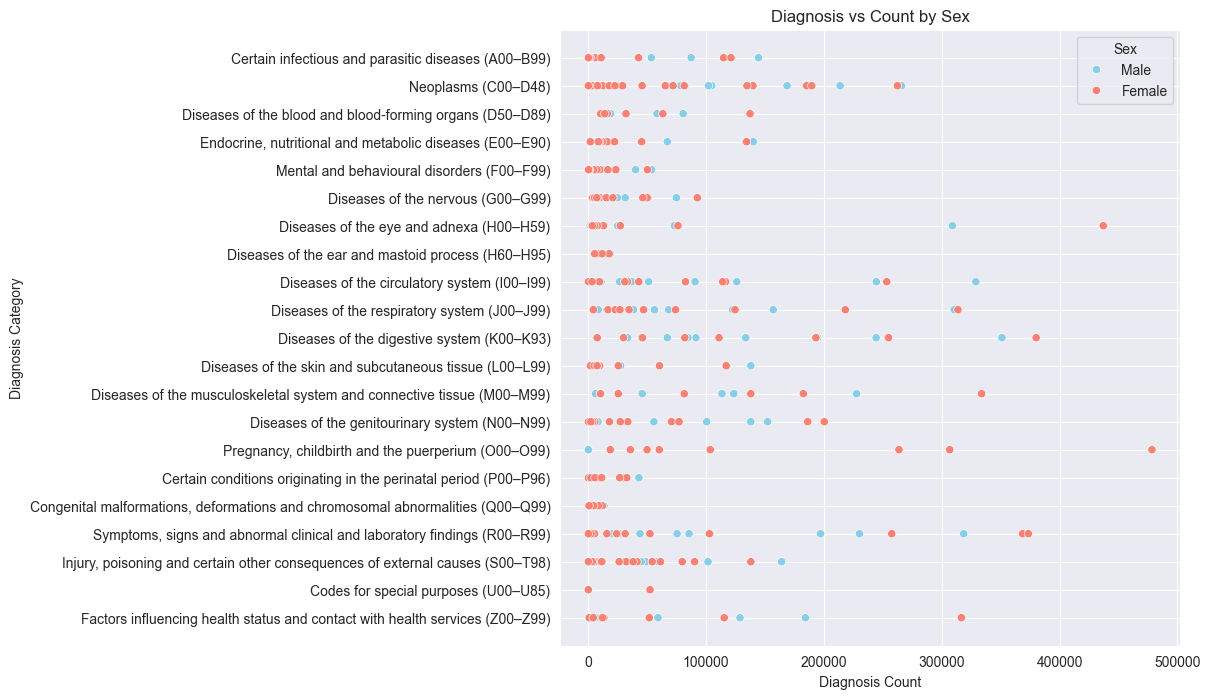

In [81]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=diagnosis_summary_df, y='category', x='diagnosis_count', hue='sex', palette=palette)
plt.title('Diagnosis vs Count by Sex')
plt.xlabel('Diagnosis Count')
plt.ylabel('Diagnosis Category')
plt.legend(title='Sex')

Plotting the diagnosis counts by category in a scatter graph shows the spread of diagnosis counts by catgeory, and there are no significant outliers. Outliers did not cause an issue when processing this data as it is already aggregated and of a high quality due to being sourced from the NHS.

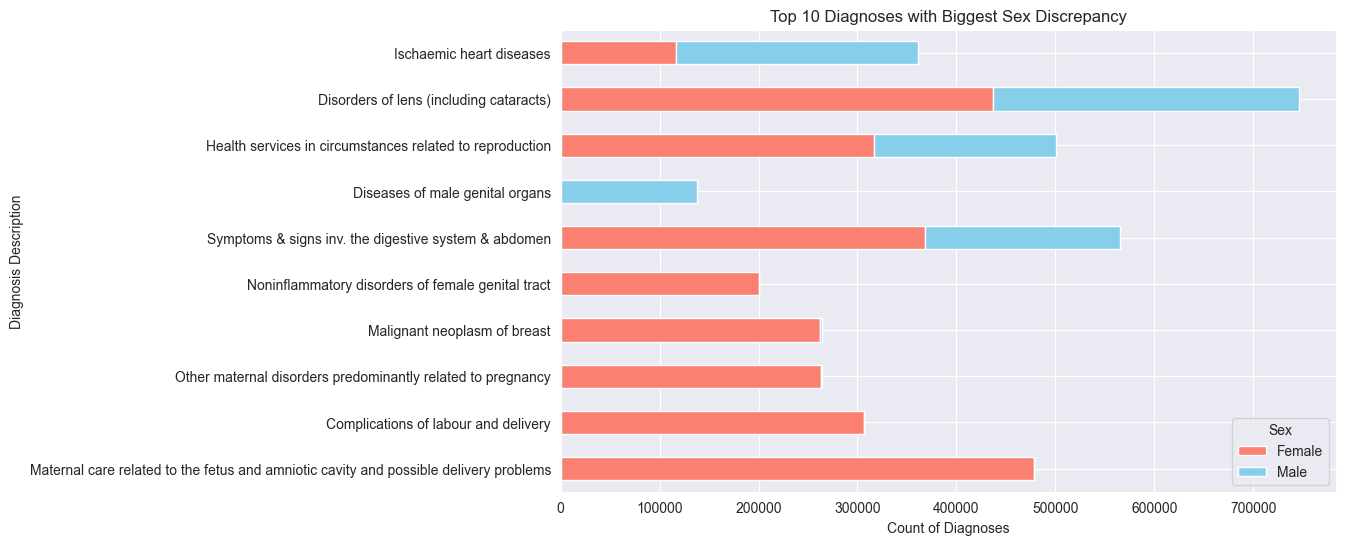

In [82]:
discrepancy_df = diagnosis_summary_wide.copy()
discrepancy_df['discrepancy'] = abs(discrepancy_df['Female'] - discrepancy_df['Male'])

top_discrepancy_diagnoses = discrepancy_df.sort_values(by='discrepancy', ascending=False).head(10)

top_discrepancy_diagnoses[['Female', 'Male']].plot(kind='barh', stacked=True, color=['salmon', 'skyblue'])

plt.title('Top 10 Diagnoses with Biggest Sex Discrepancy')
plt.xlabel('Count of Diagnoses')
plt.ylabel('Diagnosis Description')
plt.legend(title='Sex')
plt.show()

Text(0, 0.5, 'Category')

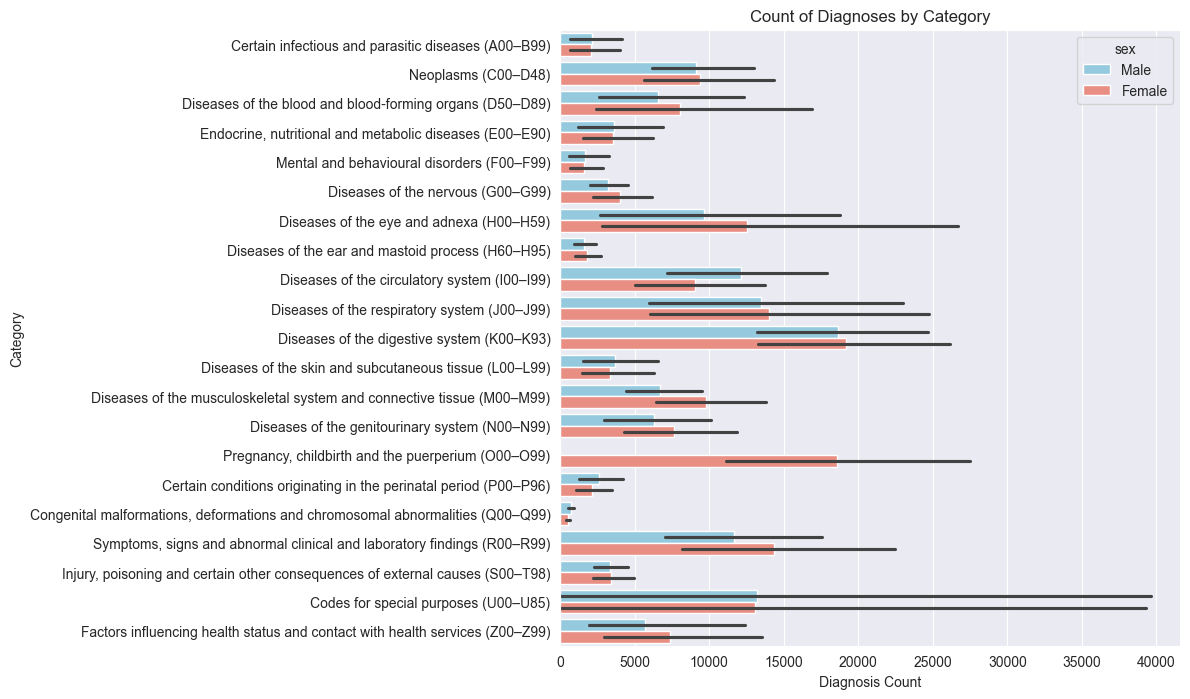

In [83]:
plt.figure(figsize=(8, 8))
category_plot = sns.barplot(diagnosis_3_char_df, x='diagnosis_count', y='category', hue='sex', palette=palette)
plt.title('Count of Diagnoses by Category')
plt.xlabel('Diagnosis Count')
plt.ylabel('Category')

Categories with significant differences between male and female (excluding pregancy):
* Diseases of the blood and blood–forming organs
* Diseases of the eye and adnexa
* Diseases of the circulatory system
* Diseases of the musculoskeletal system and connective tissue
* Symptoms, signs and abnormal clinical and laboratory findings
* Factors influencing health status and contact with health services

Text(0, 0.5, 'Count')

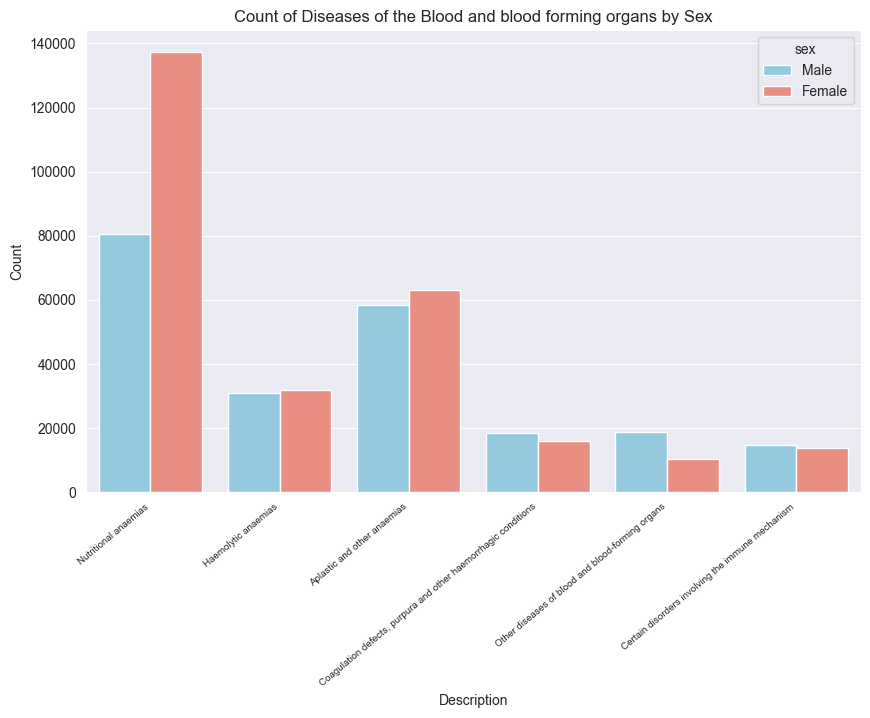

In [84]:
blood_diag_df = diagnosis_summary_df[diagnosis_summary_df['category'].str.contains('blood')]
blood_plot = sns.barplot(blood_diag_df, x='description', y='diagnosis_count', hue='sex', palette=palette)
plt.xticks(rotation=40, ha="right", fontsize=7)
plt.title('Count of Diseases of the Blood and blood forming organs by Sex')
plt.xlabel('Description')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

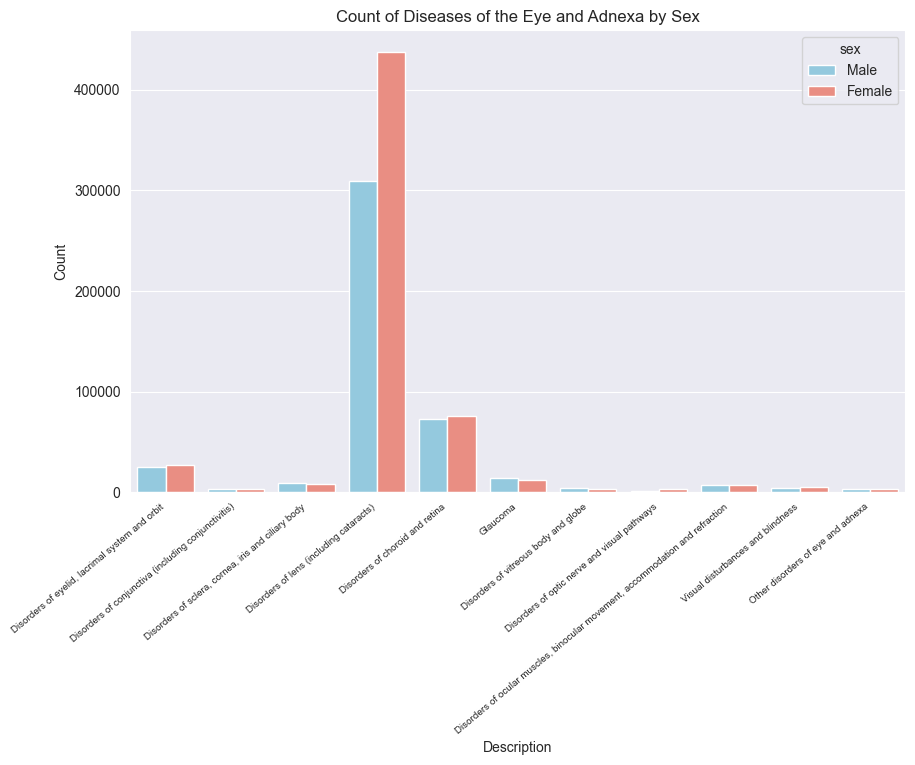

In [85]:
adnexa_diag_df = diagnosis_summary_df[diagnosis_summary_df['category'].str.contains('adnexa')]
adnexa_plot = sns.barplot(adnexa_diag_df, x='description', y='diagnosis_count', hue='sex', palette=palette)
plt.xticks(rotation=40, ha="right", fontsize=7)
plt.title('Count of Diseases of the Eye and Adnexa by Sex')
plt.xlabel('Description')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

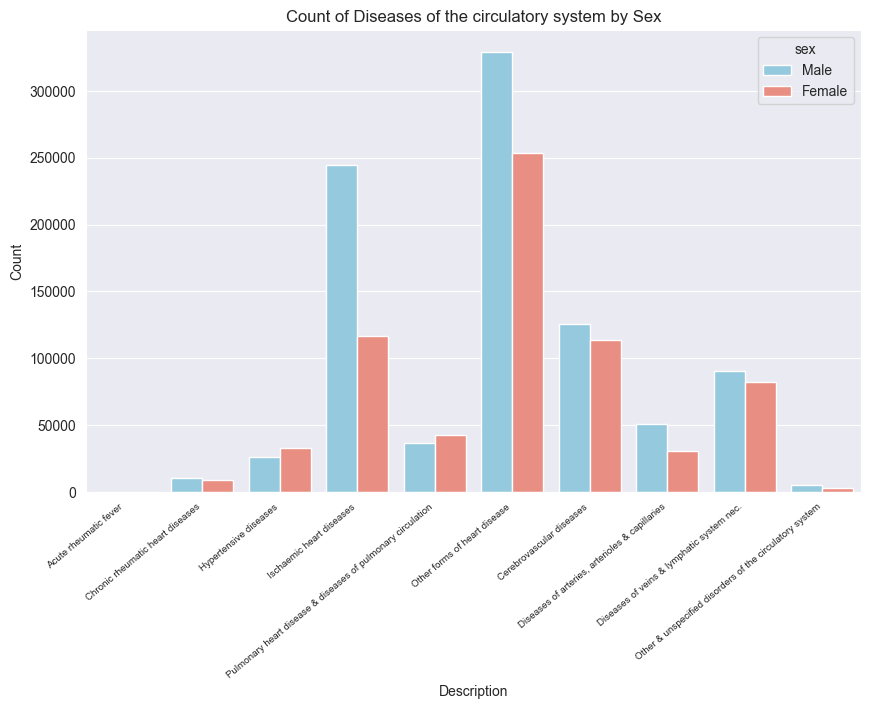

In [86]:
circ_diag_df = diagnosis_summary_df[diagnosis_summary_df['category'].str.contains('circulatory')]
circ_plot = sns.barplot(circ_diag_df, x='description', y='diagnosis_count', hue='sex', palette=palette)
plt.xticks(rotation=40, ha="right", fontsize=7)
plt.title('Count of Diseases of the circulatory system by Sex')
plt.xlabel('Description')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

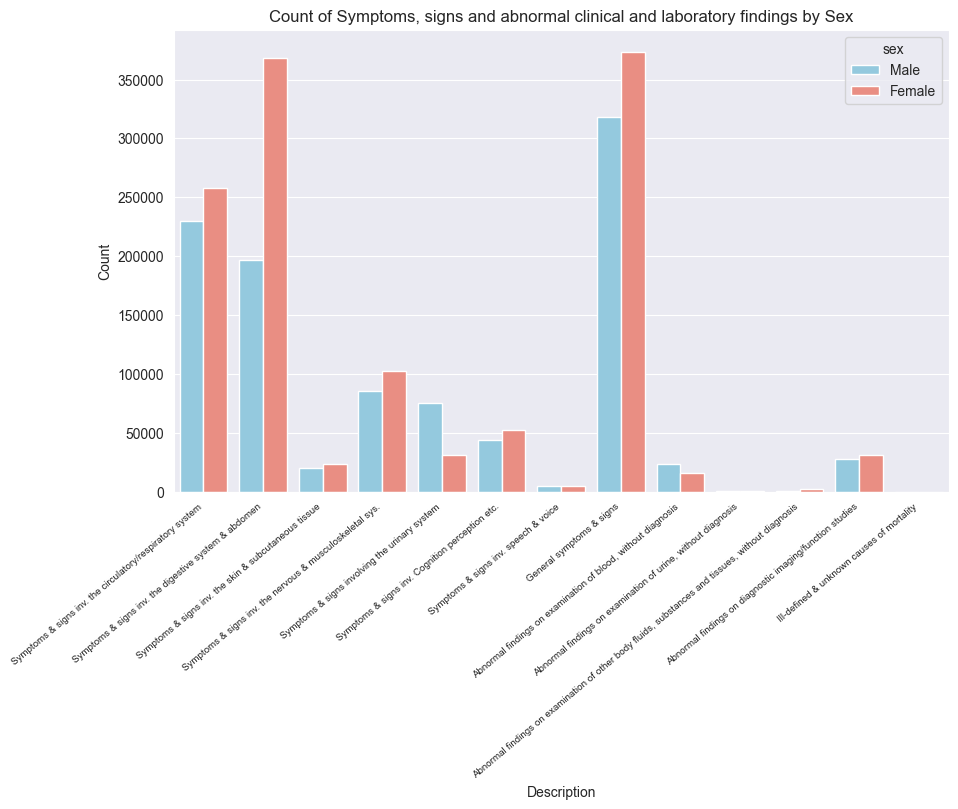

In [87]:
signs_diag_df = diagnosis_summary_df[diagnosis_summary_df['category'].str.contains('R00')]
signs_plot = sns.barplot(signs_diag_df, x='description', y='diagnosis_count', hue='sex', palette=palette)
plt.xticks(rotation=40, ha="right", fontsize=7)
plt.title('Count of Symptoms, signs and abnormal clinical and laboratory findings by Sex')
plt.xlabel('Description')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

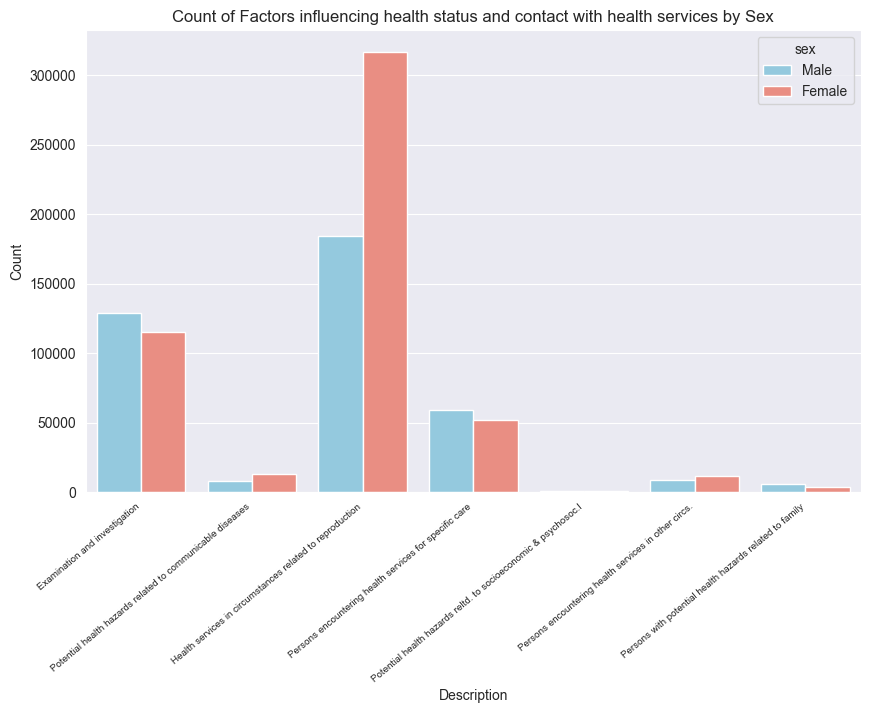

In [88]:
factors_diag_df = diagnosis_summary_df[diagnosis_summary_df['category'].str.contains('Z00')]
factors_plot = sns.barplot(factors_diag_df, x='description', y='diagnosis_count', hue='sex', palette=palette)
plt.xticks(rotation=40, ha="right", fontsize=7)
plt.title('Count of Factors influencing health status and contact with health services by Sex')
plt.xlabel('Description')
plt.ylabel('Count')

Types of injury may suggest differences in behaviour patterns.

The plot below shows:
* Male patients received a greater number of head, arm and hand injuries which could correlate with sports or manual work which are more commonly associated with men.
* Female patients had higher numbers of injuries to the lower body. The pelvis, hips and spine can be affected by pregnancy and childbirth, which may be a factor.

Text(0, 0.5, 'Count')

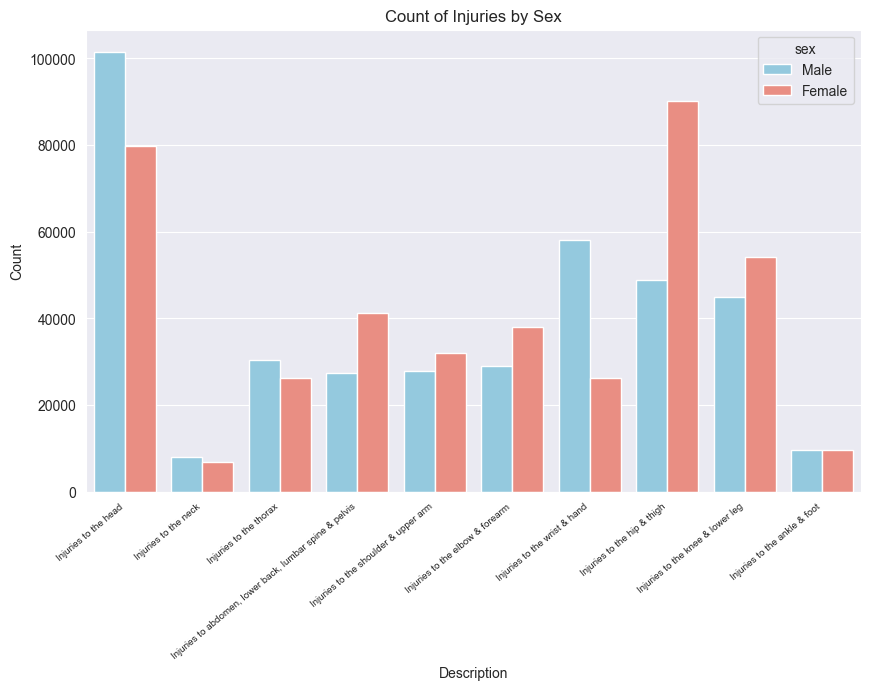

In [89]:
injuries_diag_df = diagnosis_summary_df[diagnosis_summary_df['code'].map(lambda x: x.startswith('S'))]
injuries_plot = sns.barplot(injuries_diag_df, x='description', y='diagnosis_count', hue='sex', palette=palette)
plt.xticks(rotation=40, ha="right", fontsize=7)
plt.title('Count of Injuries by Sex')
plt.xlabel('Description')
plt.ylabel('Count')

Women received more diagnoses overall

Women received a higher proportion of the most common diagnoses when individual descriptions and total overall numbers were taken into account.

In most categories where there were notable differences between diagnoses given to male and female patients, a greater number were given to women - with the exception of heart disease.

Injuries show differences that may correlate with physical differences but also behaviour patterns.

Beyond diagnoses explicitly relating to reproduction, women received noticeable higher diagnoses of:

- cataracts
- anaemia
- symptoms relating to the digestive system and abdomen

Preventative measures in these areas could help address the balance of healthcare needs across men and women.

The data counts consultant episodes (i.e. individual instances of attending hospital and receiving a diagnosis) rather than individual patients, so inflated numbers for women may also include repeated visits by certain individuals. This could suggest poorer health overall, or multiple visits being required before a final diagnosis is reached.

## Hospital Admitted Patient Care - Procedures

In [34]:
analysis_df = pd.read_csv("../data/clean/cleaned_procedures_analysis.csv")
analysis_df.head()

,procedure_group,male_fce,female_fce
0,A1 Tissue of brain (A01-A11),5491,4382
1,A2 Ventricle of brain and subarachnoid space (...,3706,3695
2,A3 Cranial nerves (A24-A36),1462,1851
3,A4 Meninges of brain (A38-A43),3541,2663
4,A5 Spinal cord and other contents of spinal ca...,61877,79476


In [35]:
total_male = analysis_df['male_fce'].sum()
total_female = analysis_df['female_fce'].sum()

total_male, total_female

(np.int64(5830142), np.int64(6863739))

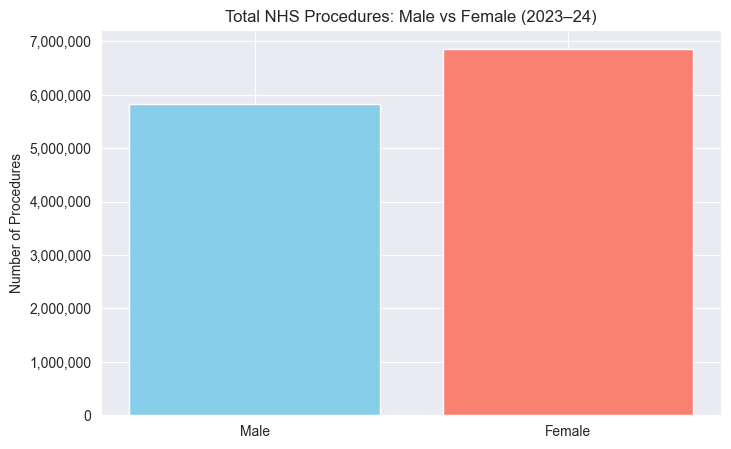

In [36]:
plt.figure(figsize=(8,5))
plt.bar(['Male', 'Female'], [total_male, total_female], color=["skyblue", "salmon"])
plt.title('Total NHS Procedures: Male vs Female (2023–24)')
plt.ylabel('Number of Procedures')

# Show full numbers instead of 1e6
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.show()

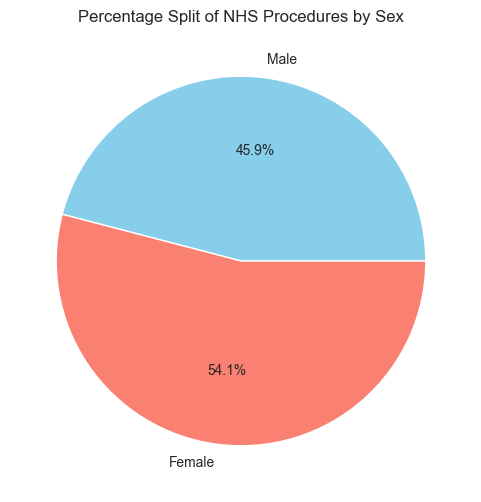

In [37]:
totals = {'Male': total_male, 'Female': total_female}
plt.figure(figsize=(6,6))
plt.pie(totals.values(), labels=totals.keys(), autopct="%1.1f%%", colors=["skyblue", "salmon"])
plt.title("Percentage Split of NHS Procedures by Sex")
plt.show()

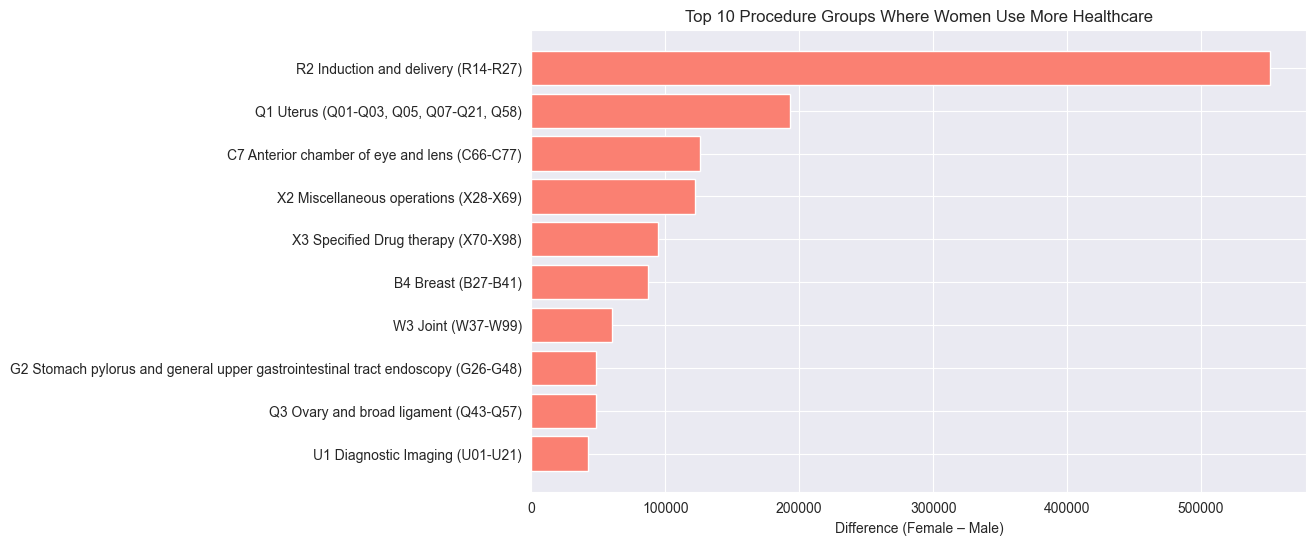

In [38]:
diff_df = analysis_df.copy()
diff_df['difference'] = diff_df['female_fce'] - diff_df['male_fce']
top_female = diff_df.nlargest(10, 'difference')

plt.figure(figsize=(10,6))
plt.barh(top_female['procedure_group'], top_female['difference'], color="salmon")
plt.title("Top 10 Procedure Groups Where Women Use More Healthcare")
plt.xlabel("Difference (Female – Male)")
plt.gca().invert_yaxis()
plt.show()

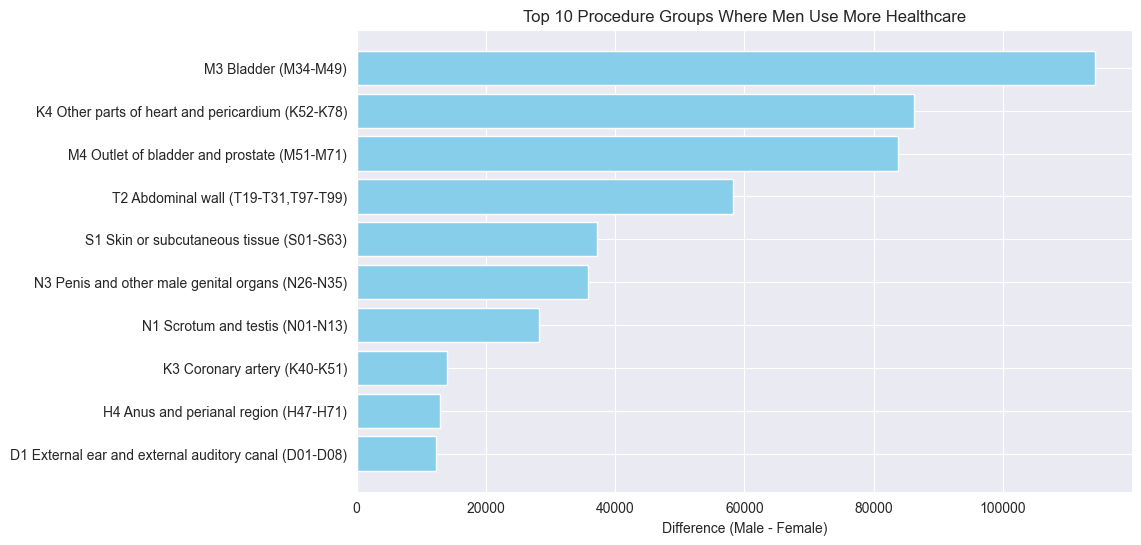

In [39]:
diff_df = analysis_df.copy()
diff_df['difference'] = diff_df['male_fce'] - diff_df['female_fce']
top_female = diff_df.nlargest(10, 'difference')

plt.figure(figsize=(10,6))
plt.barh(top_female['procedure_group'], top_female['difference'], color="skyblue")
plt.title("Top 10 Procedure Groups Where Men Use More Healthcare")
plt.xlabel("Difference (Male - Female)")
plt.gca().invert_yaxis()
plt.show()

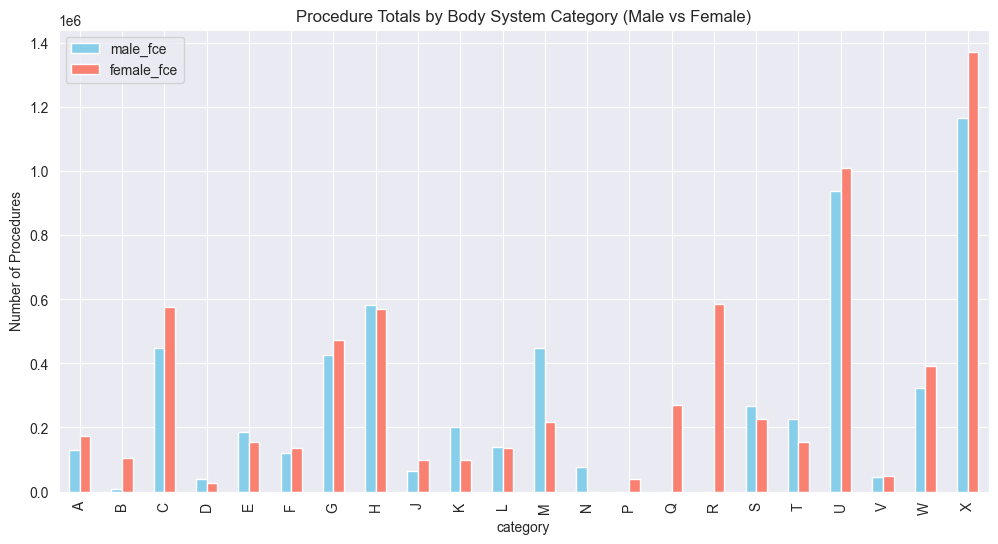

In [40]:
analysis_df['category'] = analysis_df['procedure_group'].str[0]  # first letter (S, T, U, W, etc.)
category_totals = analysis_df.groupby('category')[['male_fce','female_fce']].sum()

category_totals.plot(kind="bar", figsize=(12,6), color=["skyblue", "salmon"])
plt.title("Procedure Totals by Body System Category (Male vs Female)")
plt.ylabel("Number of Procedures")
plt.show()

In [41]:
analysis_df['prefix'] = analysis_df['procedure_group'].str.extract(r'^([A-Z]\d)')

In [42]:
key_table = (
    analysis_df[['prefix', 'procedure_group']]
    .drop_duplicates('prefix')
    .assign(description=lambda df: df['procedure_group'].str.extract(r'^[A-Z]\d\s(.+?)\s?\(')[0])
    [['prefix', 'description']]
    .sort_values('prefix')
    .reset_index(drop=True)
)

key_table

,prefix,description
0,A1,Tissue of brain
1,A2,Ventricle of brain and subarachnoid space
2,A3,Cranial nerves
3,A4,Meninges of brain
4,A5,Spinal cord and other contents of spinal canal
...,...,...
95,W3,Joint
96,W4,Overflow other bones and joints
97,X1,Operations covering multiple systems
98,X2,Miscellaneous operations


<Axes: ylabel='procedure_group'>

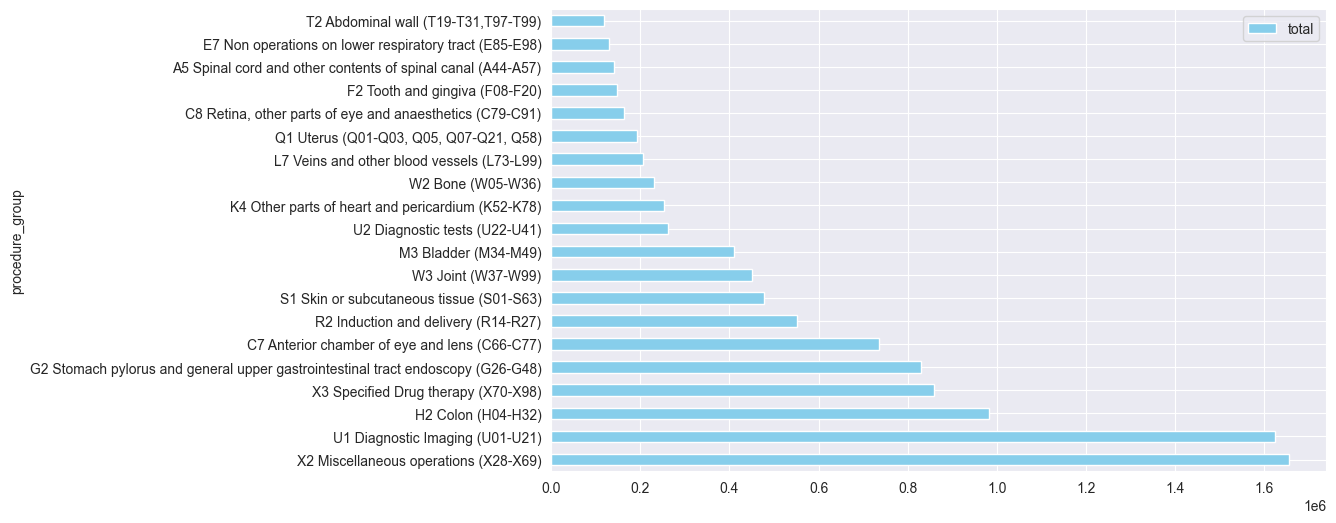

In [43]:
analysis_df['total'] = analysis_df['male_fce'] + analysis_df['female_fce']
top20 = analysis_df.nlargest(20, 'total')

top20.plot(x='procedure_group', y='total', kind='barh', color='skyblue')

In [44]:
# Create a total column just for sorting
analysis_df['total_fce'] = analysis_df['male_fce'] + analysis_df['female_fce']

# Pick top 10 procedures by total FCE
top10 = (
    analysis_df
    .sort_values('total_fce', ascending=False)
    .head(10)
    .copy()
)

top10

,procedure_group,male_fce,female_fce,category,prefix,total,total_fce
98,X2 Miscellaneous operations (X28-X69),767143,888960,X,X2,1656103,1656103
88,U1 Diagnostic Imaging (U01-U21),790908,833152,U,U1,1624060,1624060
41,H2 Colon (H04-H32),490813,491946,H,H2,982759,982759
99,X3 Specified Drug therapy (X70-X98),381968,476251,X,X3,858219,858219
36,G2 Stomach pylorus and general upper gastroint...,390403,438758,G,G2,829161,829161
17,C7 Anterior chamber of eye and lens (C66-C77),304891,430967,C,C7,735858,735858
76,R2 Induction and delivery (R14-R27),1,551172,R,R2,551173,551173
79,S1 Skin or subcutaneous tissue (S01-S63),257200,220011,S,S1,477211,477211
95,W3 Joint (W37-W99),195311,255638,W,W3,450949,450949
64,M3 Bladder (M34-M49),262645,148387,M,M3,411032,411032


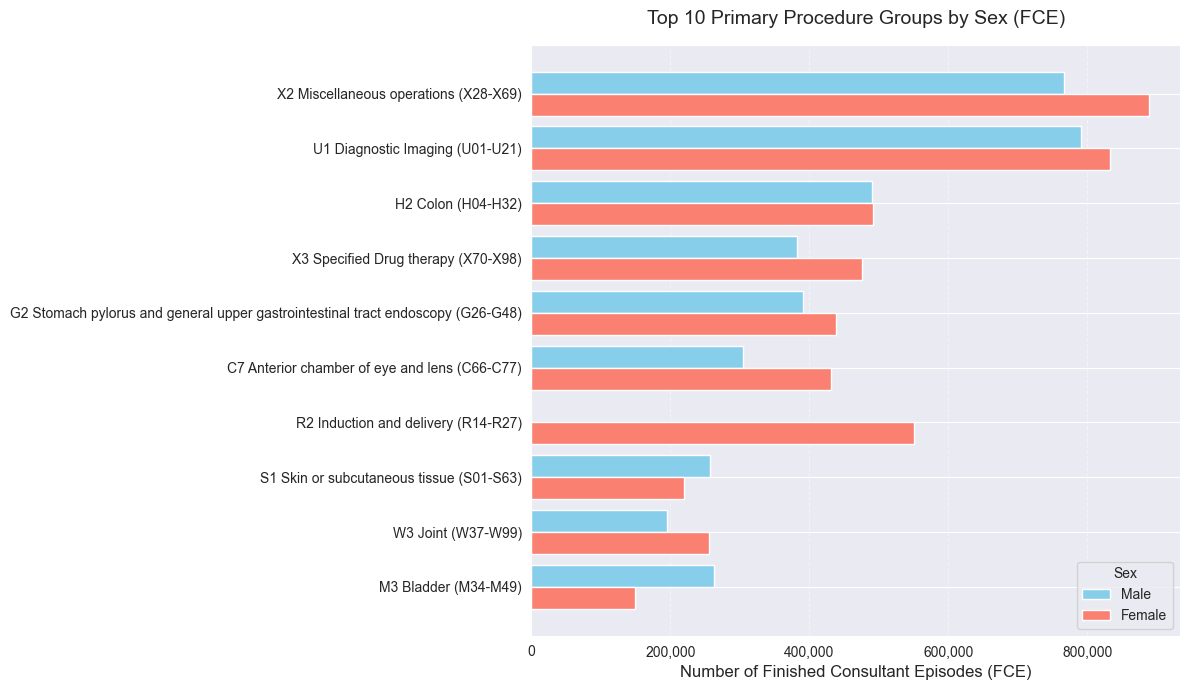

In [45]:
x = np.arange(len(top10))
bar_height = 0.4

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(x - bar_height/2, top10['male_fce'],  height=bar_height, label='Male', color="skyblue")
ax.barh(x + bar_height/2, top10['female_fce'], height=bar_height, label='Female', color="salmon")


ax.set_yticks(x)
ax.set_yticklabels(top10['procedure_group'])


ax.invert_yaxis()

# Titles & labels
ax.set_title("Top 10 Primary Procedure Groups by Sex (FCE)", fontsize=14, pad=15)
ax.set_xlabel("Number of Finished Consultant Episodes (FCE)", fontsize=12)

# Format x-axis with commas
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))


ax.legend(title="Sex")


ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Patient Level Activity 2021-22

The Patient Level Information and Costing Systems (PLICS) data collection records activity and cost information for acute, mental health and ambulance services in England.

In [46]:
file_path = "../data/raw/Integrated-Patient-Level-Activity-and-Costing-2021-22.csv"

activity_21_22_df = pd.read_csv(file_path)

# light clean
activity_21_22_df["BREAKDOWN_GROUP_1"] = activity_21_22_df["BREAKDOWN_GROUP_1"].astype(str).str.strip()
activity_21_22_df["BREAKDOWN_GROUP_2"] = activity_21_22_df["BREAKDOWN_GROUP_2"].astype(str).str.strip()
activity_21_22_df["ACTIVITY_COUNT"] = pd.to_numeric(activity_21_22_df["ACTIVITY_COUNT"], errors="coerce")
activity_21_22_df["TOTAL_COST"] = pd.to_numeric(activity_21_22_df["TOTAL_COST"], errors="coerce")
activity_21_22_df = activity_21_22_df.dropna(subset=["ACTIVITY_COUNT", "TOTAL_COST"], how="all")

# focus only on Male / Female
gender_df = activity_21_22_df[activity_21_22_df["BREAKDOWN_GROUP_1"].isin(["Male", "Female"])].copy()

# age rows
age_df = gender_df[
    gender_df["BREAKDOWN_GROUP_2"].str.contains("years", case=False, na=False)
].copy()

# sorting age bands
def get_start_age(age_text: str) -> int:
    first = age_text.split("-")[0].split()[0]
    return int(first)

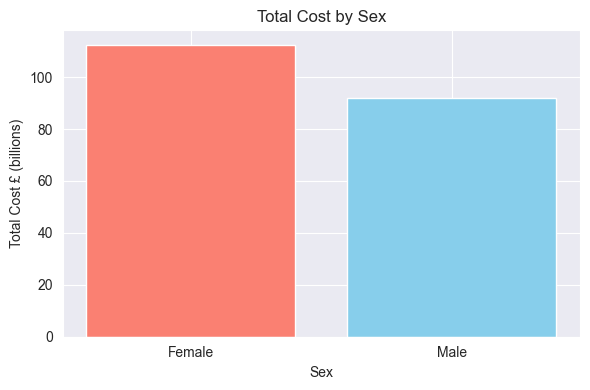

In [90]:
gender_cost = (
    gender_df.groupby("BREAKDOWN_GROUP_1")[["TOTAL_COST"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(6,4))
plt.bar(gender_cost["BREAKDOWN_GROUP_1"], gender_cost["TOTAL_COST"] /1e9, color=my_colours) # 1e9 tells the number of zeros in this case 9
plt.title("Total Cost by Sex")
plt.xlabel("Sex")
plt.ylabel("Total Cost £ (billions)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}")) # reformats it to the appropriate decimal place on the x-axis
plt.tight_layout()
plt.show()

**Plot Summary**
- Women's health costs more on the NHS than Men

**Interpretation**
- Data suggests that spending on the NHS is greater for Women than it is for Men
- These figures reflect healthcare usage costs, so can be deemed a trustworthy reliable indicator
- The chart provides context for gender-based spending patterns across the NHS

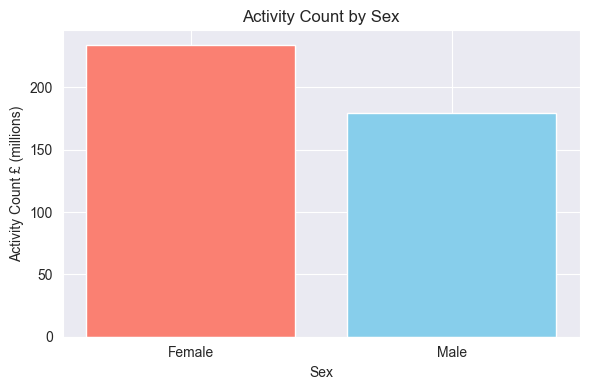

In [91]:
gender_activity = (
    gender_df
    .groupby("BREAKDOWN_GROUP_1")[["ACTIVITY_COUNT"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(6, 4))
plt.bar(gender_activity["BREAKDOWN_GROUP_1"], gender_activity["ACTIVITY_COUNT"] / 1e6, color=my_colours) # 6 zeros
plt.title("Activity Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Activity Count £ (millions)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}")) # to the decimal place
plt.tight_layout()
plt.show()

**Plot Summary**
- Overall women tend to access and use NHS Services more so than Men

**Interpretation**
- Data suggests that spending on the NHS is greater for Women than it is for Men
- These figures reflect healthcare usage costs, so can be deemed a trustworthy reliable indicator
- The chart provides context for gender-based spending patterns across the NHS

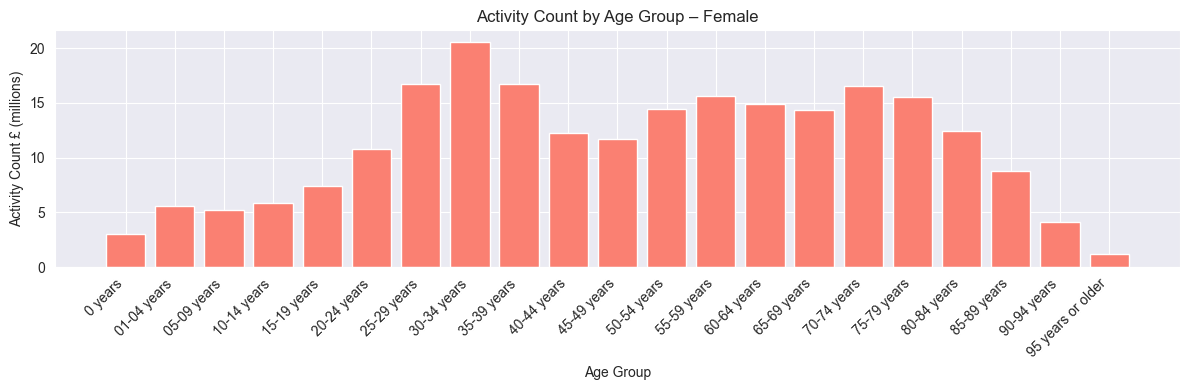

In [49]:
plt.show()
female_age = age_df[age_df["BREAKDOWN_GROUP_1"] == "Female"].copy()

female_age = (
    female_age
    .groupby("BREAKDOWN_GROUP_2")[["ACTIVITY_COUNT"]]
    .sum()
    .reset_index()
)

female_age["AGE_SORT"] = female_age["BREAKDOWN_GROUP_2"].apply(get_start_age)
female_age = female_age.sort_values("AGE_SORT")

plt.figure(figsize=(12, 4))
plt.bar(female_age["BREAKDOWN_GROUP_2"], female_age["ACTIVITY_COUNT"] / 1e6, color="salmon")
plt.title("Activity Count by Age Group – Female")
plt.xlabel("Age Group")
plt.ylabel("Activity Count £ (millions)")
plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

**Plot Summary**
- Across their 'child-bearing' years ,Women tend to use NHS Services more so in earlier life than Men

**Interpretation**
- Data suggests that spending on the NHS is greater for Women earlier than it is for Women
- These figures reflect healthcare usage costs, so can be deemed a trustworthy reliable indicator
- The chart provides context for gender-based spending patterns across the NHS

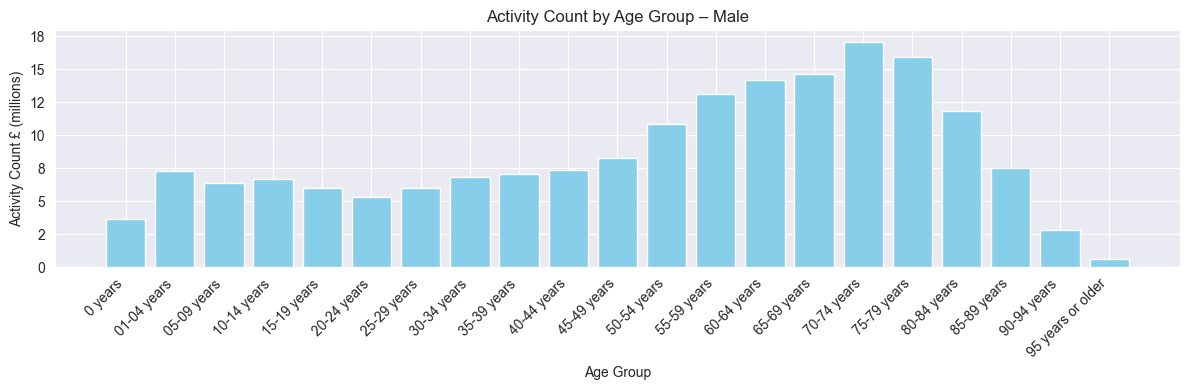

In [50]:
plt.show()
male_age = age_df[age_df["BREAKDOWN_GROUP_1"] == "Male"].copy()

male_age = (
    male_age
    .groupby("BREAKDOWN_GROUP_2")[["ACTIVITY_COUNT"]]
    .sum()
    .reset_index()
)

male_age["AGE_SORT"] = male_age["BREAKDOWN_GROUP_2"].apply(get_start_age)
male_age = male_age.sort_values("AGE_SORT")

plt.figure(figsize=(12, 4))
plt.bar(male_age["BREAKDOWN_GROUP_2"], male_age["ACTIVITY_COUNT"] / 1e6, color="skyblue")
plt.title("Activity Count by Age Group – Male")
plt.xlabel("Age Group")
plt.ylabel("Activity Count £ (millions)")
plt.xticks(rotation=45, ha="right")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

**Plot Summary**
- Across their later years, men tend to use NHS Services more so in later life than women

**Interpretation**
- Data suggests that spending on the NHS is greater for Men later than it is for Women
- These figures reflect healthcare usage costs, so can be deemed a trustworthy reliable indicator
- The chart provides context for gender-based spending patterns across the NHS

### Patient Level Activity and Costing 2019-20 vs 2021-2022

In [113]:
activity_19_20_df = pd.read_csv('../data/clean/patient_level_activity_2019_20_cleaned.csv')

activity_19_20_df.head()

,BREAKDOWN,BREAKDOWN_GROUP_1,BREAKDOWN_GROUP_2,TOTAL_COST
0,Gender and Age Group,Female,0 years,212079
1,Gender and Age Group,Female,01-04 years,505885
2,Gender and Age Group,Female,05-09 years,347081
3,Gender and Age Group,Female,10-14 years,371563
4,Gender and Age Group,Female,15-19 years,483626


In [112]:
new_21_22_df = gender_df.assign(YEAR='2021-22')
new_21_22_df = new_21_22_df[["BREAKDOWN", "BREAKDOWN_GROUP_1", "BREAKDOWN_GROUP_2", "TOTAL_COST", "YEAR"]].copy()
new_21_22_df.head()

,BREAKDOWN,BREAKDOWN_GROUP_1,BREAKDOWN_GROUP_2,TOTAL_COST,YEAR
6,Sex and Age Group,Female,80-84 years,1.609173e+09,2021-22
7,Sex and Age Group,Female,85-89 years,1.457331e+09,2021-22
8,Sex and Age Group,Female,90-94 years,8.870095e+08,2021-22
37,Sex and Age Group,Female,0 years,3.540552e+07,2021-22
38,Sex and Age Group,Female,01-04 years,9.171168e+07,2021-22


In [95]:
new_19_20_df = activity_19_20_df.assign(YEAR='2019-20')
new_19_20_df.head()

,BREAKDOWN,BREAKDOWN_GROUP_1,BREAKDOWN_GROUP_2,TOTAL_COST,YEAR
0,Gender and Age Group,Female,0 years,212079,2019-20
1,Gender and Age Group,Female,01-04 years,505885,2019-20
2,Gender and Age Group,Female,05-09 years,347081,2019-20
3,Gender and Age Group,Female,10-14 years,371563,2019-20
4,Gender and Age Group,Female,15-19 years,483626,2019-20


In [115]:
frames = [new_19_20_df, new_21_22_df]
combined_activity = pd.concat(frames)
display(combined_activity)

,BREAKDOWN,BREAKDOWN_GROUP_1,BREAKDOWN_GROUP_2,TOTAL_COST,YEAR
0,Gender and Age Group,Female,0 years,212079.00,2019-20
1,Gender and Age Group,Female,01-04 years,505885.00,2019-20
2,Gender and Age Group,Female,05-09 years,347081.00,2019-20
3,Gender and Age Group,Female,10-14 years,371563.00,2019-20
4,Gender and Age Group,Female,15-19 years,483626.00,2019-20
...,...,...,...,...,...
48177,Sex and Age Group,Male,50-54 years,1411202.89,2021-22
48178,Sex and Age Group,Male,50-54 years,1036995.85,2021-22
48179,Sex and Age Group,Male,55-59 years,619563.05,2021-22
48180,Sex and Age Group,Male,55-59 years,217744.15,2021-22


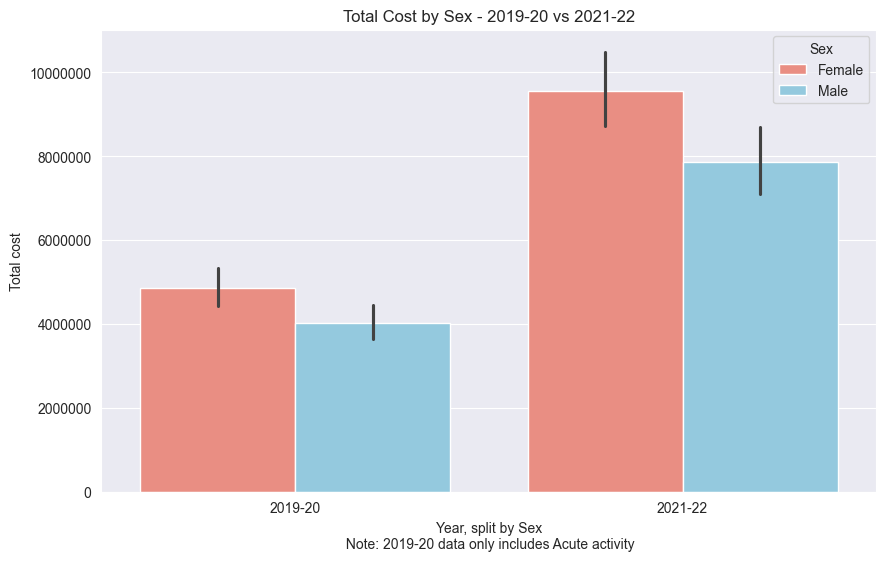

In [116]:
palette = {"Female": "salmon", "Male": "skyblue"}

sns.barplot(
    data=combined_activity, x="YEAR", y="TOTAL_COST", hue="BREAKDOWN_GROUP_1", palette=palette
)
plt.title('Total Cost by Sex - 2019-20 vs 2021-22')
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
plt.xlabel('Year, split by Sex\n Note: 2019-20 data only includes Acute activity')
plt.ylabel('Total cost')
plt.legend(title="Sex")

In [117]:
# Creating new df to group cost by gender & year, adding new column with percentage

grouped_cost = combined_activity.groupby(['YEAR', 'BREAKDOWN_GROUP_1'])['TOTAL_COST'].sum().reset_index()
grouped_cost['PERCENTAGE_COST'] = grouped_cost.groupby('YEAR')['TOTAL_COST'].transform(lambda x: x / x.sum())
display(grouped_cost)

,YEAR,BREAKDOWN_GROUP_1,TOTAL_COST,PERCENTAGE_COST
0,2019-20,Female,9.166183e+10,0.549639
1,2019-20,Male,7.510537e+10,0.450361
2,2021-22,Female,1.123709e+11,0.550259
3,2021-22,Male,9.184361e+10,0.449741


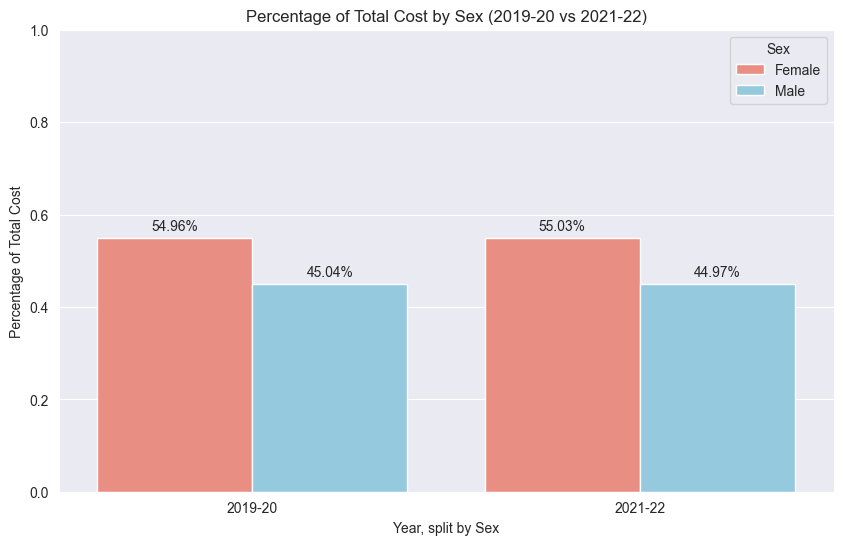

In [118]:
percent_split_plot = sns.barplot(data=grouped_cost, x='YEAR', y='PERCENTAGE_COST', hue='BREAKDOWN_GROUP_1', palette=palette)
plt.title('Percentage of Total Cost by Sex (2019-20 vs 2021-22)')
plt.xlabel('Year, split by Sex')
plt.ylabel('Percentage of Total Cost')
plt.legend(title='Sex')
plt.ylim(0, 1)
for container in percent_split_plot.containers:
    labels = [f"{v.get_height():.2%}" for v in container]
    percent_split_plot.bar_label(container, labels=labels, padding=3)
plt.show()

**Plot Summary:**

Spending split by sex has remained very stable over the two year groups. Female spending remains around 55% and Male at 45%.

In [120]:
# Creating new df to group cost by age group, as well as gender & year, adding new column with percentage

age_grouped_cost = combined_activity.groupby(['YEAR', 'BREAKDOWN_GROUP_1', 'BREAKDOWN_GROUP_2'])['TOTAL_COST'].sum().reset_index()
age_grouped_cost['PERCENTAGE_COST'] = age_grouped_cost.groupby('YEAR')['TOTAL_COST'].transform(lambda x: x / x.sum())
display(age_grouped_cost)

,YEAR,BREAKDOWN_GROUP_1,BREAKDOWN_GROUP_2,TOTAL_COST,PERCENTAGE_COST
0,2019-20,Female,0 years,1.358065e+09,0.008143
1,2019-20,Female,01-04 years,1.652912e+09,0.009911
2,2019-20,Female,05-09 years,1.499475e+09,0.008991
3,2019-20,Female,10-14 years,1.749887e+09,0.010493
4,2019-20,Female,15-19 years,2.324587e+09,0.013939
...,...,...,...,...,...
83,2021-22,Male,80-84 years,7.778362e+09,0.038089
84,2021-22,Male,85-89 years,5.777802e+09,0.028293
85,2021-22,Male,90-94 years,2.650643e+09,0.012980
86,2021-22,Male,95 years or older,6.341790e+08,0.003105


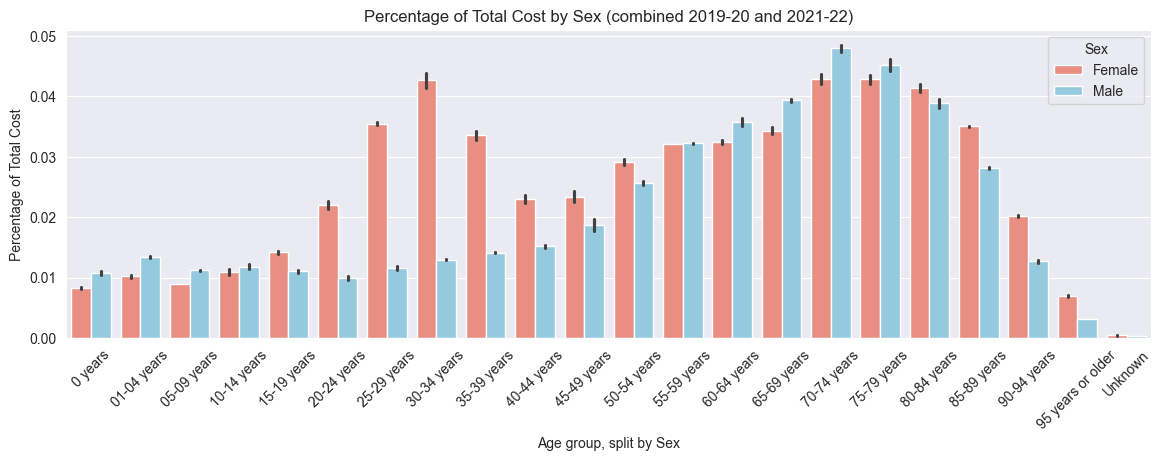

In [121]:
# Plot to show percentage of cost by gender and age group
plt.figure(figsize=(14, 4))

age_percentage_plot = sns.barplot(data=age_grouped_cost, x='BREAKDOWN_GROUP_2', y='PERCENTAGE_COST', hue='BREAKDOWN_GROUP_1', palette=palette)
plt.title('Percentage of Total Cost by Sex (combined 2019-20 and 2021-22)')
plt.xlabel('Age group, split by Sex')
plt.ylabel('Percentage of Total Cost')
plt.legend(title='Sex')
plt.xticks(rotation=45)
plt.show()

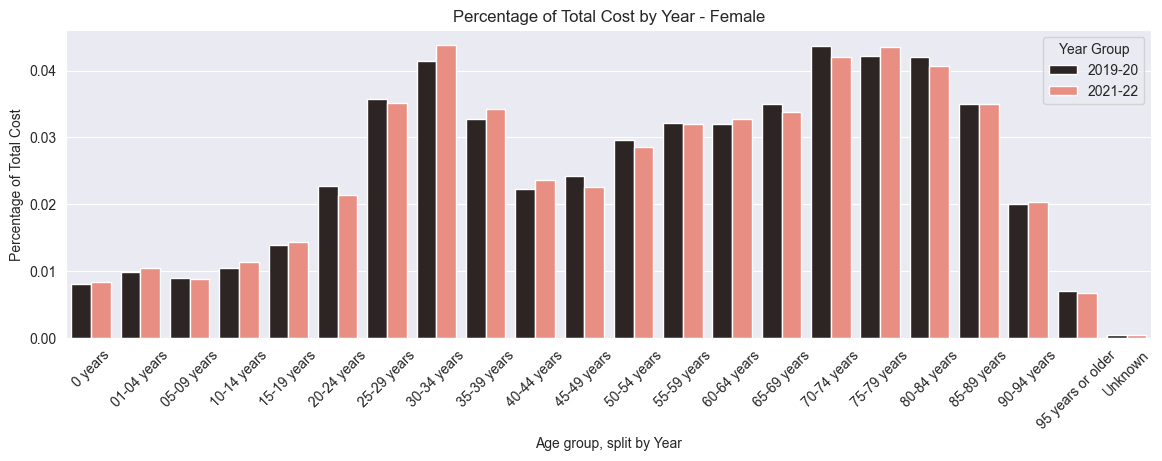

In [122]:
# Plot to show percentage of cost by age group and year

age_grouped_female = age_grouped_cost[age_grouped_cost["BREAKDOWN_GROUP_1"].isin(["Female"])].copy()
plt.figure(figsize=(14, 4))

age_percentage_plot = sns.barplot(data=age_grouped_female, x='BREAKDOWN_GROUP_2', y='PERCENTAGE_COST', hue='YEAR', palette='dark:salmon')
plt.title('Percentage of Total Cost by Year - Female')
plt.xlabel('Age group, split by Year')
plt.ylabel('Percentage of Total Cost')
plt.legend(title='Year Group')
plt.xticks(rotation=45)
plt.show()

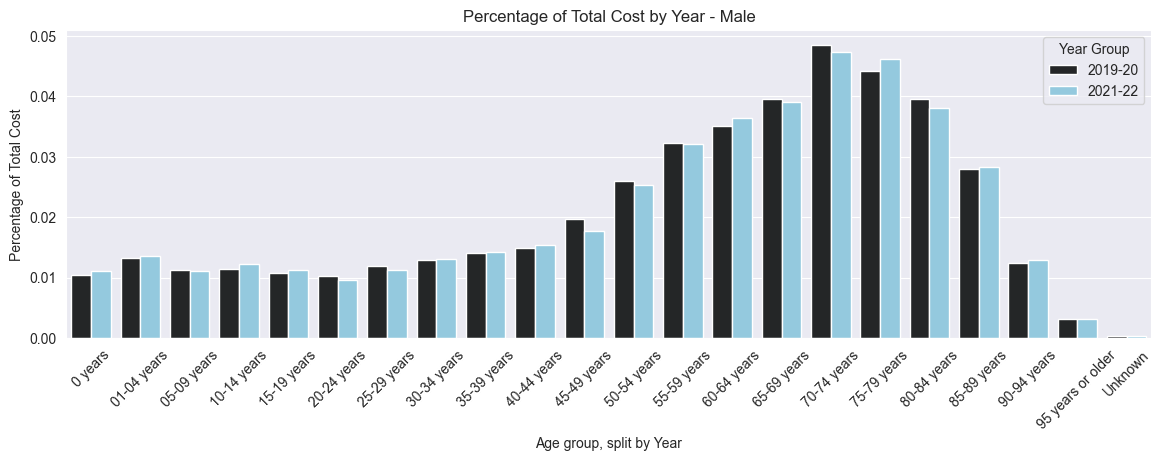

In [123]:
# Plot to show percentage of cost by age group and year

age_grouped_male = age_grouped_cost[age_grouped_cost["BREAKDOWN_GROUP_1"].isin(["Male"])].copy()
plt.figure(figsize=(14, 4))

age_percentage_plot = sns.barplot(data=age_grouped_male, x='BREAKDOWN_GROUP_2', y='PERCENTAGE_COST', hue='YEAR', palette='dark:skyblue')
plt.title('Percentage of Total Cost by Year - Male')
plt.xlabel('Age group, split by Year')
plt.ylabel('Percentage of Total Cost')
plt.legend(title='Year Group')
plt.xticks(rotation=45)
plt.show()

### UK Health Accounts

In [55]:
csv_path = '../data/clean/UK_Accounts_expenditure_by_function_clean.csv'

# Read the csv and check first few rows
health_df = pd.read_csv(csv_path)

plt.rcParams['figure.figsize'] = (10, 6)

In [56]:
# Changing data types
provider_cols = [col for col in health_df.columns if col != 'healthcare_function']

for col in provider_cols:
  health_df[col] = pd.to_numeric(health_df[col], errors='coerce')

provider_cols = [col for col in health_df.columns if col != 'healthcare_function']

provider_totals = health_df[provider_cols].sum().sort_values(ascending=False)

#### Total healthcare expenditure by provider type
This chart shows how total UK health spending (in the UK Health Accounts) is distributed across different provider types such as hospitals, residential long-term care and ambulatory care.

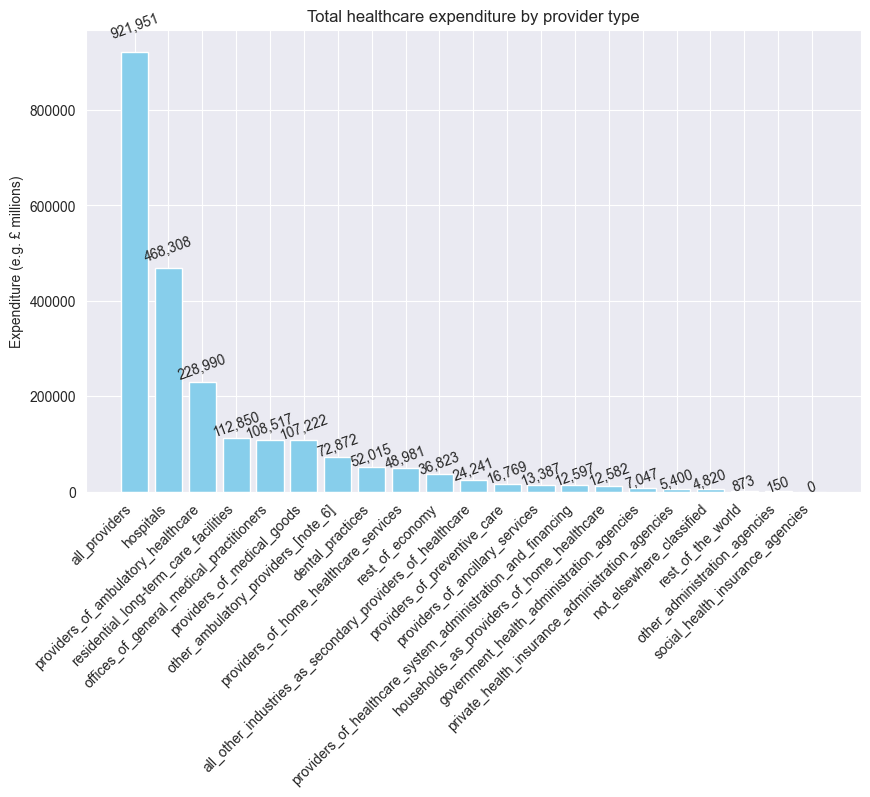

In [58]:
# Identify providers and calculate the sum expenditure across all functions for each provider

provider_cols = [col for col in health_df.columns if col != 'healthcare_function']
provider_totals = health_df[provider_cols].sum().sort_values(ascending=False)

plt.figure()

plt.bar(provider_totals.index, provider_totals.values, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Expenditure (e.g. £ millions)')
plt.title('Total healthcare expenditure by provider type')

# Amended to rotate values above bars as they were overlapping
# for i, value in enumerate(provider_totals.values):
  # plt.text(i, value, f'{value:,.0f}', ha='center', va='bottom', fontsize=8)

for i, value in enumerate(provider_totals.values):
  plt.text(i, value + (value * 0.03),
           f'{value:,.0f}',
           ha='center', rotation=20)

plt.tight_layout
plt.show()

#### Healthcare expenditure by function (all providers)

This chart shows which functions cost the most across all providers.

In [59]:
function_total_col = 'all_providers'

# Sort functions by total spend and view top 10
top_functions = health_df.sort_values(function_total_col, ascending=False).head(10)

top_functions[['healthcare_function', function_total_col]]

,healthcare_function,all_providers
0,All functions,297994.0
1,Curative / rehabilitative care,176984.0
4,Outpatient curative / rehabilitative care,80727.0
2,Inpatient curative / rehabilitative inpatient ...,74149.0
14,Long-term care (health),57387.0
15,Inpatient long-term care (health),38790.0
20,Medical goods,33584.0
21,Pharmaceuticals and other medical non-durable ...,28819.0
18,Home-based long-term care (health),18382.0
22,Prescribed medicines,17548.0


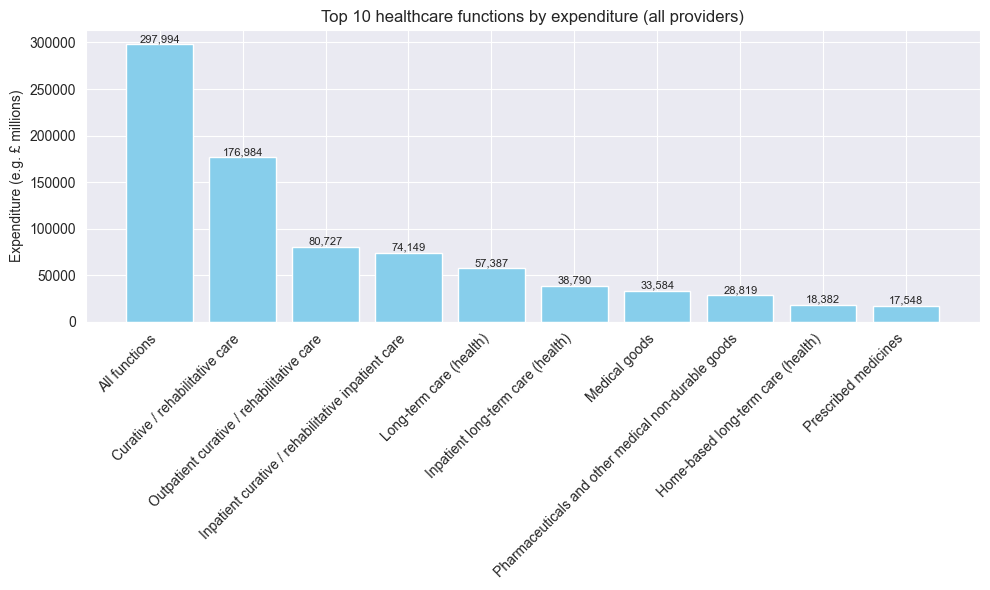

In [61]:
plt.figure()

plt.bar(top_functions['healthcare_function'], top_functions[function_total_col], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Expenditure (e.g. £ millions)')
plt.title('Top 10 healthcare functions by expenditure (all providers)')

for i, value in enumerate(top_functions[function_total_col].values):
  plt.text(i, value, f'{value:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

**Plots Summary:**

These charts show how total UK healthcare spending is distributed across a variety of provider types such as hospitals, long-term care and general practice. It highlights that hospitals account for one of the largest proportions of overall health expenditure. When we connect this with our demographic analysis where we found that women consistently have more inpatient episodes than men across nearly all ethnic groups, we gain important context. If women use more hospital care and hospital care is among the most expensive then differences might be driven partly by higher utilisation of high-cost services by women.

### UK Health Accounts - Current Expenditure

In [62]:
csv_path = '../data/clean/UK_Accounts_current_expenditure_real_clean.csv'

health_raw = pd.read_csv(csv_path, header=0)

health_raw.head(10)

,financing_scheme,1997,1998,1999,2000,2001,2002,2003,2004,2005,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024_[note_10]
0,Total current healthcare expenditure,123029.0,129413.0,135726.0,142609.0,152173.0,163829.0,173115.0,183298.0,189716.0,...,253719.0,256694.0,258963.0,265099.0,274570.0,298641.0,323598.0,311685.0,309914.0,317411.0
1,Government-financed expenditure,91095.0,96458.0,102788.0,107522.0,114861.0,125143.0,134808.0,146133.0,153348.0,...,200258.0,203915.0,204318.0,208654.0,217006.0,249381.0,269235.0,254083.0,251716.0,258060.0
2,Voluntary health insurance schemes,4637.0,4795.0,5061.0,6066.0,6744.0,6929.0,6911.0,6976.0,7510.0,...,8182.0,7108.0,7632.0,7705.0,7795.0,7040.0,7180.0,7845.0,8032.0,8344.0
3,Non-profit institutions serving households fin...,1357.0,1490.0,1626.0,1808.0,1923.0,2117.0,2357.0,2313.0,2445.0,...,4176.0,4612.0,5225.0,5058.0,4949.0,4599.0,4531.0,4445.0,4332.0,4308.0
4,Enterprise financing schemes,1342.0,1392.0,1184.0,1233.0,1183.0,1153.0,1076.0,936.0,934.0,...,850.0,810.0,798.0,792.0,788.0,560.0,511.0,488.0,495.0,498.0
5,Out-of-pocket expenditure,24599.0,25278.0,25067.0,25979.0,27463.0,28487.0,27963.0,26940.0,25479.0,...,40254.0,40249.0,40990.0,42889.0,44032.0,37061.0,42142.0,44824.0,45338.0,46200.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Current healthcare expenditure excludes expend...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Financing scheme (HF) refers to the method of ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
# Light cleaning

health_raw.columns = health_raw.columns.str.replace(r'\[.*\]', '', regex=True )

health_raw.columns = health_raw.columns.str.strip()

year_cols = [col for col in health_raw.columns if col != 'financing_scheme']

health_df = health_raw.copy()

for col in year_cols:
  health_df[col] = pd.to_numeric(health_df[col], errors='coerce')

health_df = health_df.dropna(subset=year_cols, how='all')

health_df.head(10)

,financing_scheme,1997,1998,1999,2000,2001,2002,2003,2004,2005,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024_
0,Total current healthcare expenditure,123029.0,129413.0,135726.0,142609.0,152173.0,163829.0,173115.0,183298.0,189716.0,...,253719.0,256694.0,258963.0,265099.0,274570.0,298641.0,323598.0,311685.0,309914.0,317411.0
1,Government-financed expenditure,91095.0,96458.0,102788.0,107522.0,114861.0,125143.0,134808.0,146133.0,153348.0,...,200258.0,203915.0,204318.0,208654.0,217006.0,249381.0,269235.0,254083.0,251716.0,258060.0
2,Voluntary health insurance schemes,4637.0,4795.0,5061.0,6066.0,6744.0,6929.0,6911.0,6976.0,7510.0,...,8182.0,7108.0,7632.0,7705.0,7795.0,7040.0,7180.0,7845.0,8032.0,8344.0
3,Non-profit institutions serving households fin...,1357.0,1490.0,1626.0,1808.0,1923.0,2117.0,2357.0,2313.0,2445.0,...,4176.0,4612.0,5225.0,5058.0,4949.0,4599.0,4531.0,4445.0,4332.0,4308.0
4,Enterprise financing schemes,1342.0,1392.0,1184.0,1233.0,1183.0,1153.0,1076.0,936.0,934.0,...,850.0,810.0,798.0,792.0,788.0,560.0,511.0,488.0,495.0,498.0
5,Out-of-pocket expenditure,24599.0,25278.0,25067.0,25979.0,27463.0,28487.0,27963.0,26940.0,25479.0,...,40254.0,40249.0,40990.0,42889.0,44032.0,37061.0,42142.0,44824.0,45338.0,46200.0


In [64]:
# Change to long format

health_long = health_df.melt(
    id_vars='financing_scheme',
    value_vars=year_cols,
    var_name='year',
    value_name='expenditure'
)

health_long['Year'] = health_long['Year'].astype(int)

health_long.head()

KeyError: 'Year'

In [65]:
# Attempting to fix error, change the years into a 'year' column

health_df = health_raw.copy()

health_df = health_df.rename(columns={'2024_': '2024'})

year_cols = [col for col in health_df.columns if col != 'financing_scheme']

for col in year_cols:
  health_df[col] = pd.to_numeric(health_df[col], errors='coerce')

health_df = health_df.dropna(subset=year_cols, how='all')

health_long = health_df.melt(
    id_vars='financing_scheme',
    value_vars=year_cols,
    var_name='Year',
    value_name='Expenditure'
)

health_long['Year'] = health_long['Year'].astype(int)

health_long.head()

,financing_scheme,Year,Expenditure
0,Total current healthcare expenditure,1997,123029.0
1,Government-financed expenditure,1997,91095.0
2,Voluntary health insurance schemes,1997,4637.0
3,Non-profit institutions serving households fin...,1997,1357.0
4,Enterprise financing schemes,1997,1342.0


#### Total current healthcare expenditure over

This chart provides some context showing that the overall cost of healthcare has increased over the years

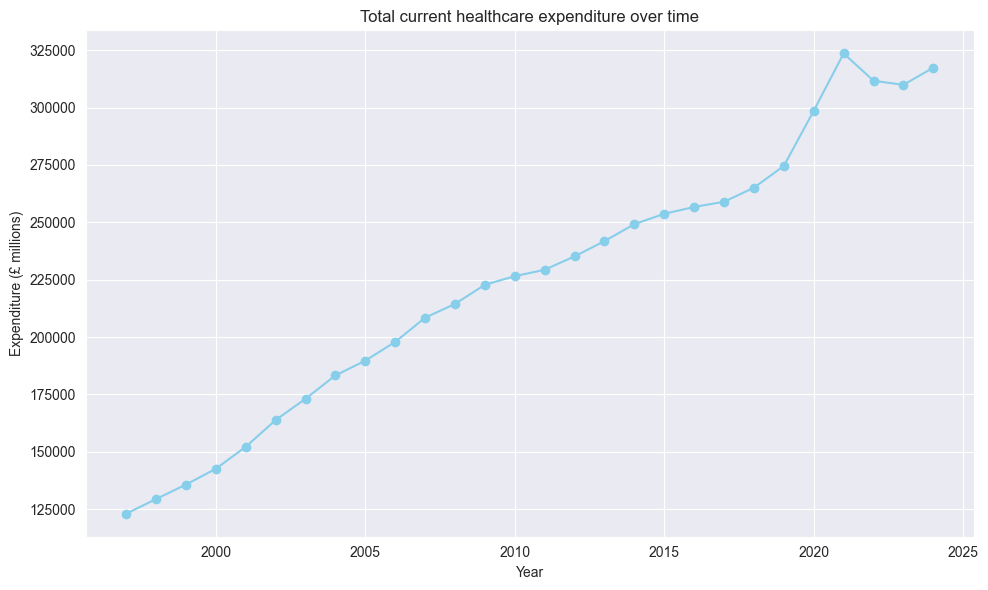

In [67]:
# Show total expenditure row only and sort by year

total_mask = health_long['financing_scheme'] == 'Total current healthcare expenditure'

total_expenditure = health_long[total_mask]

total_expenditure = total_expenditure.sort_values('Year')

plt.figure()

plt.plot(
    total_expenditure['Year'],
    total_expenditure['Expenditure'],
    marker='o',
    color='skyblue'
)

plt.title('Total current healthcare expenditure over time')
plt.xlabel('Year')
plt.ylabel('Expenditure (£ millions)')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Expenditure by finance schemes over time

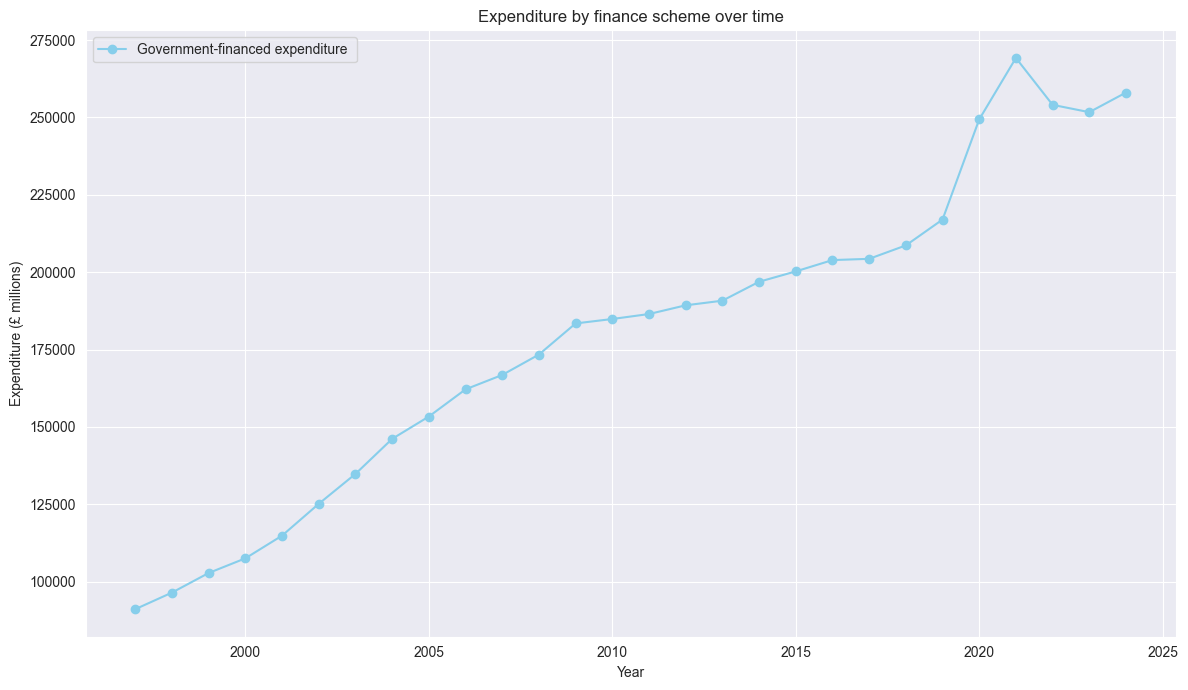

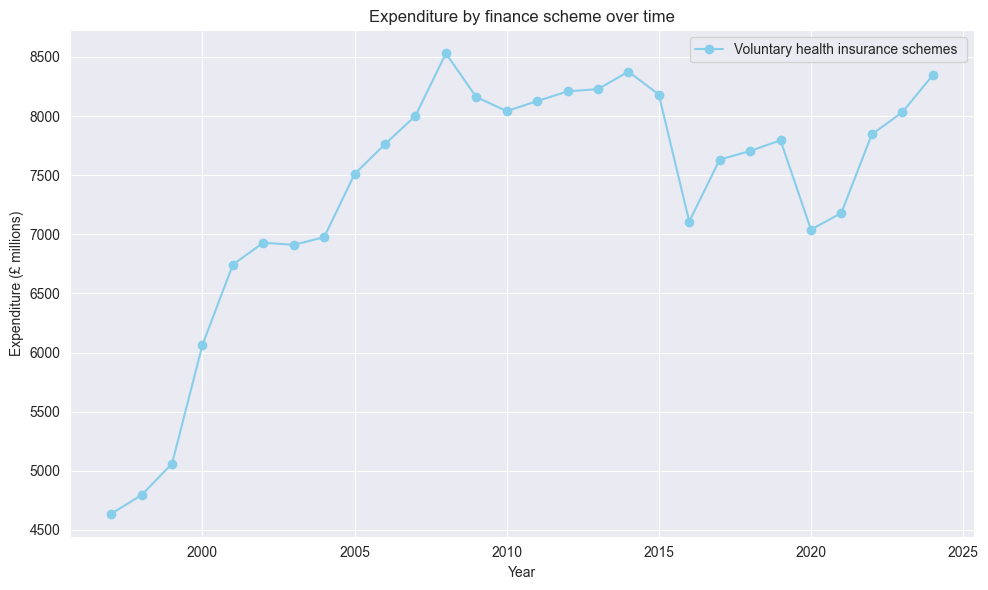

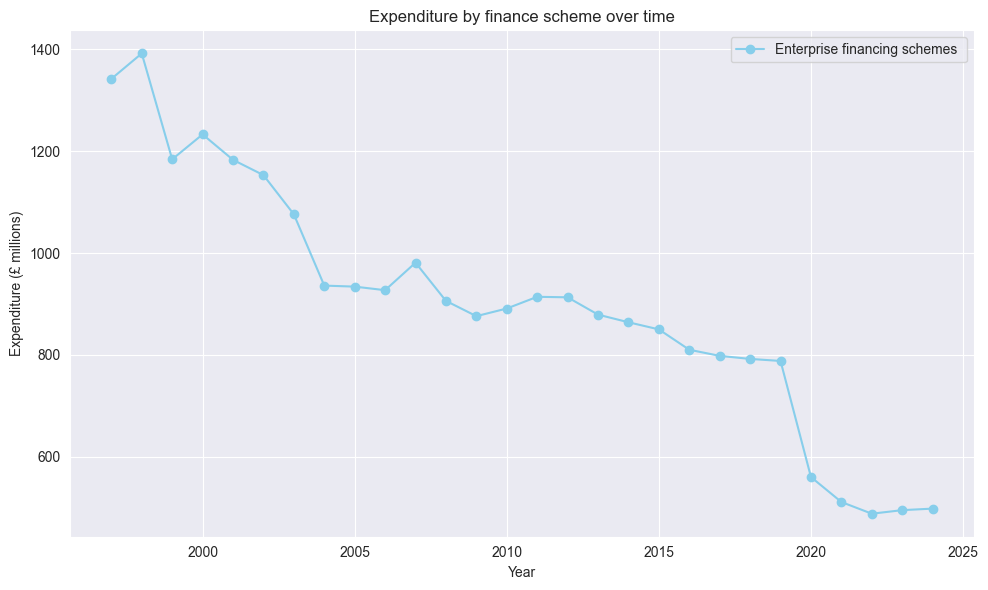

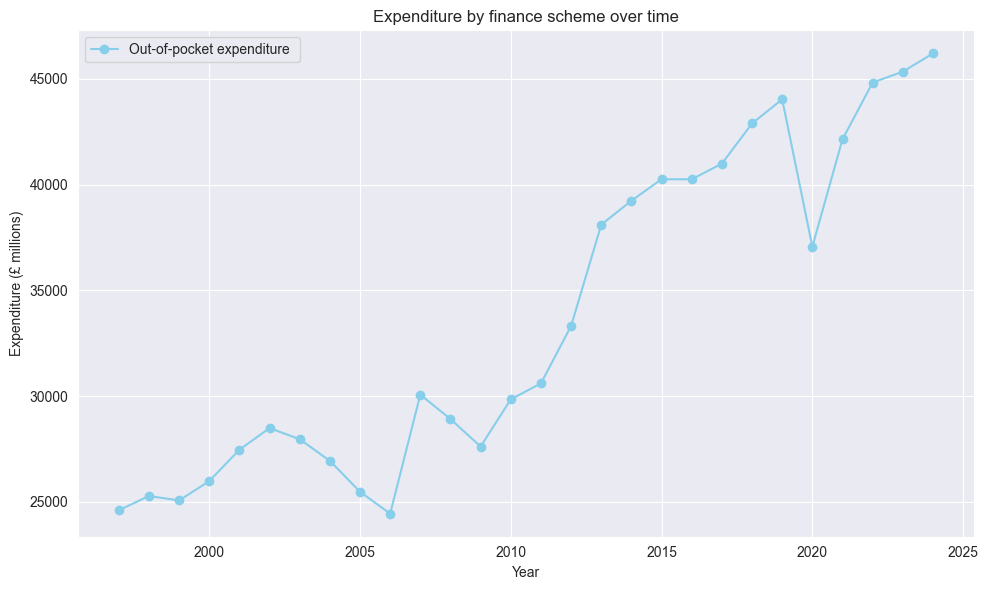

In [68]:
# Define schemes to compare

key_schemes = [
    'Government-financed expenditure ',
    'Voluntary health insurance schemes ',
    'Enterprise financing schemes ',
    'Out-of-pocket expenditure '
]

key_data = health_long[health_long['financing_scheme'].isin(key_schemes)].copy()
key_data = key_data.sort_values(['financing_scheme', 'Year'])

plt.figure(figsize=(12, 7))

for scheme in key_schemes:
  subset = key_data[key_data['financing_scheme'] == scheme]
  plt.plot(
      subset['Year'],
      subset['Expenditure'],
      marker='o',
      label=scheme,
      color='skyblue'
  )

  plt.title('Expenditure by finance scheme over time')
  plt.xlabel('Year')
  plt.ylabel('Expenditure (£ millions)')
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

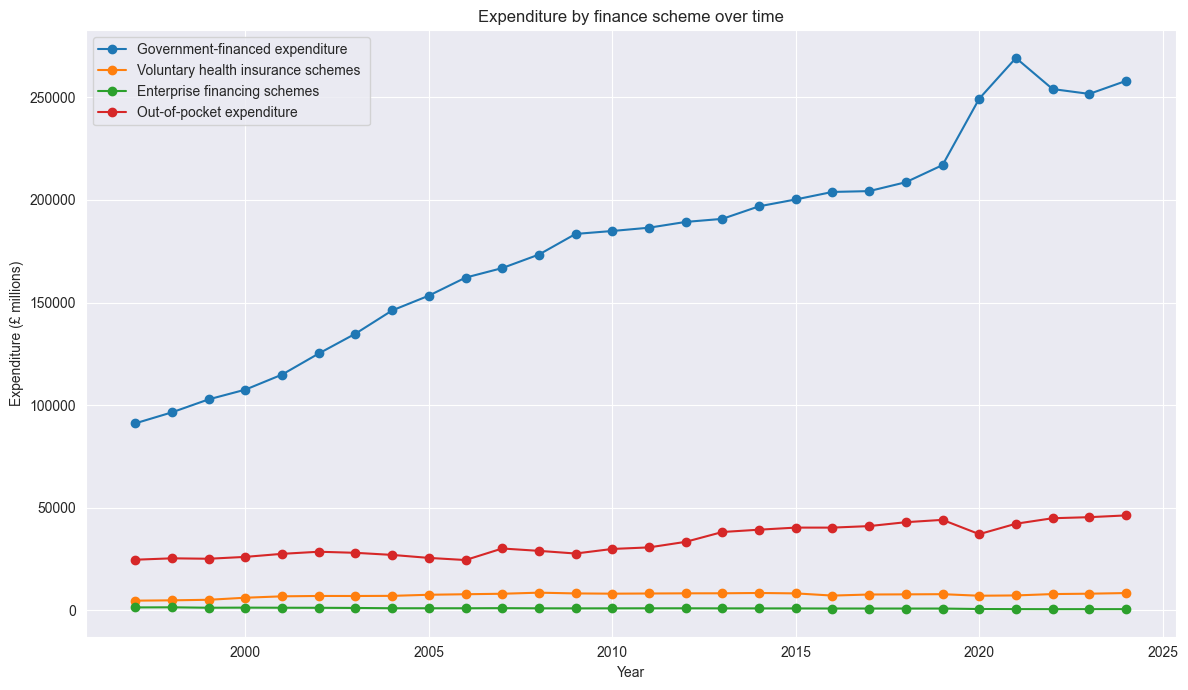

In [24]:
# Trying to make one graph not 4

key_schemes = [
    'Government-financed expenditure ',
    'Voluntary health insurance schemes ',
    'Enterprise financing schemes ',
    'Out-of-pocket expenditure '
]

key_data = health_long[health_long['financing_scheme'].isin(key_schemes)].copy()
key_data = key_data.sort_values(['financing_scheme', 'Year'])

plt.figure(figsize=(12, 7))

for scheme in key_schemes:
    subset = key_data[key_data['financing_scheme'] == scheme]
    plt.plot(
        subset['Year'],
        subset['Expenditure'],
        marker='o',
        label=scheme
    )

plt.title('Expenditure by finance scheme over time')
plt.xlabel('Year')
plt.ylabel('Expenditure (£ millions)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Plots Summary:**

These charts provide valuable insight and context into overall UK healthcare costs when evaluating gendered cost differences. UK healthcare costs are rising steeply and since out-of-pocket costs are rising, groups that use more healthcare services may disproportionately feel the financial strain.

### Fingertips API

Fingertips profiles are a rich source of indicators across a range of health and wellbeing themes. They are designed to support Joint Strategic Needs Assessment (JSNA) and commissioning to improve health and wellbeing and reduce inequalities.

In [51]:
# Reading the stored dataframe

%store -r admissions_final_df

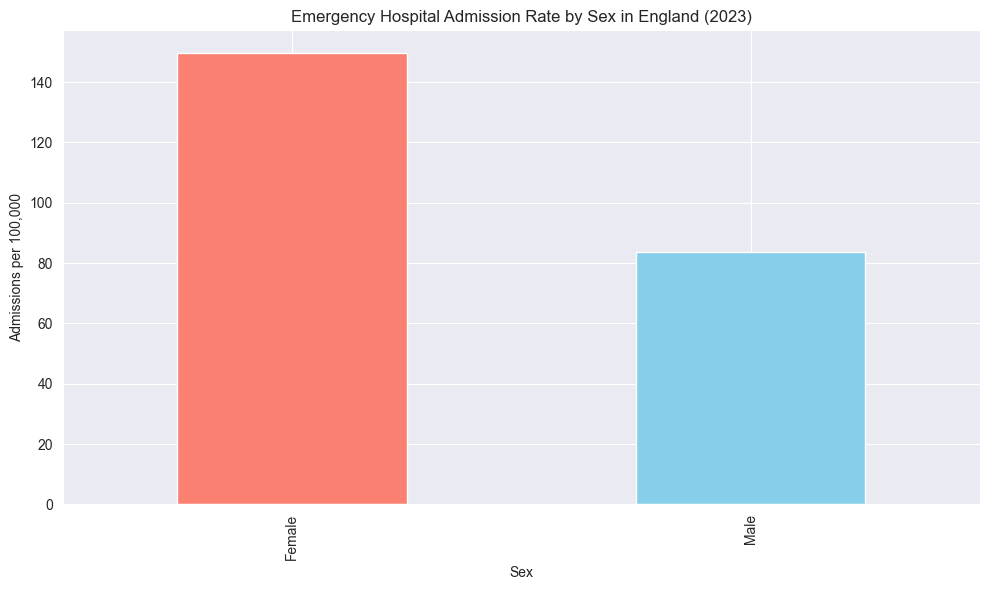

In [71]:
latest_year = admissions_final_df['Year'].max()
england_latest = admissions_final_df[
    (admissions_final_df['Area'] == 'England') &
    (admissions_final_df['Year'] == latest_year)
]

grouped = england_latest.groupby('Sex', as_index=False)['Value'].mean()

ax = grouped.plot(kind='bar', x='Sex', y='Value', legend=False, color=["salmon", "skyblue"])
ax.set_title(f"Emergency Hospital Admission Rate by Sex in England ({latest_year})")
ax.set_ylabel("Admissions per 100,000")
plt.tight_layout()
plt.show()

**Plot Summary:**

Bar plot comparing emergency hospital admission rates by sexup to the most recent year,
Females consistently show higher emergency admission rates
This implies:

- Greater demand for urgent care

- Greater short-term cost burden

- Higher pressure on NHS services from female patients in this category

Females consistently record higher emergency admission rates than males, suggesting greater usage of urgent healthcare services.

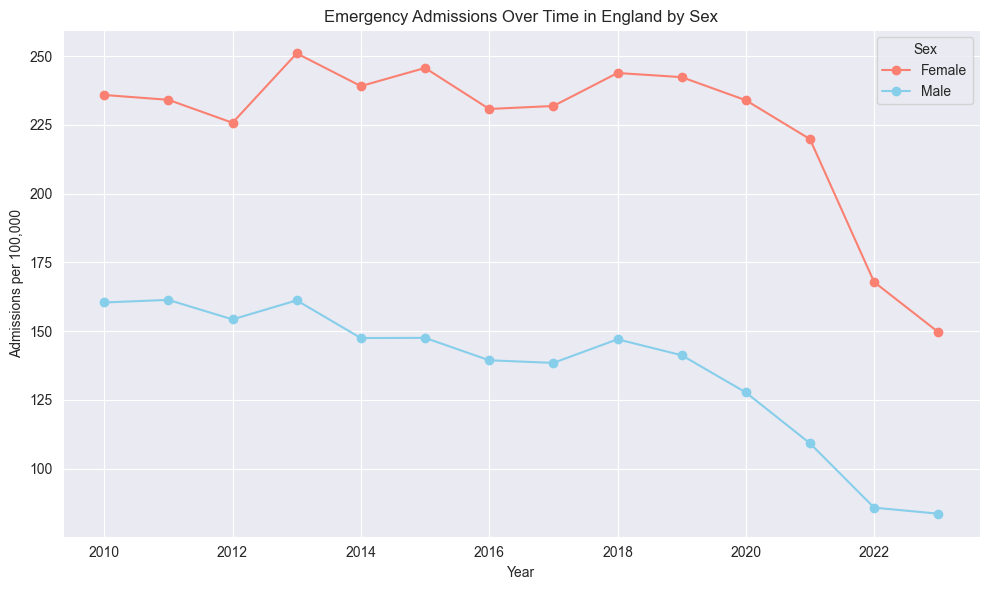

In [74]:
england_trend = admissions_final_df[
    admissions_final_df['Area'] == 'England'
].pivot_table(
    index='Year',
    columns='Sex',
    values='Value',
    aggfunc='mean'
)

ax = england_trend.plot(marker='o', color=["salmon", "skyblue"])
ax.set_title("Emergency Admissions Over Time in England by Sex")
ax.set_ylabel("Admissions per 100,000")
plt.tight_layout()
plt.show()

**Plot Summary:**

Line Chart tracking admission rates for males vs females over multple years

The difference is:

- Consistent

- Not random

- Not a one-off year spike

The gap between males and females remains stable across years, indicating a sustained difference rather than a temporary fluctuation. This suggests systematic differences in healthcare usage.

**Overall Insights:**

Emergency hospital admissions are consistently higher for females in England, and this gap remains stable over time. This indicates that women use emergency healthcare services more frequently than men, which is likely to increase overall healthcare costs through higher resource usage. This supports the idea that healthcare may be more expensive for women not due to higher treatment prices, but because of higher utilisation of high-cost services.

This dataset does not capture unit treatment cost or outpatient care. Instead, it reflects healthcare demand, which acts as a proxy for cost pressure.

## UK Health Accounts 2024 and Hospital Admitted Patient Care 2023-24

UK healthcare expenditure data by financing scheme, function and provider,

In [136]:
expenditure_function_df = pd.read_csv('../data/clean/UK_Accounts_expenditure_by_function_clean.csv')
expenditure_function_df.head()

,healthcare_function,all_providers,hospitals,residential_long-term_care_facilities,providers_of_ambulatory_healthcare,offices_of_general_medical_practitioners,dental_practices,providers_of_home_healthcare_services,other_ambulatory_providers_[note_6],providers_of_ancillary_services,...,providers_of_healthcare_system_administration_and_financing,government_health_administration_agencies,social_health_insurance_agencies,private_health_insurance_administration_agencies,other_administration_agencies,rest_of_economy,households_as_providers_of_home_healthcare,all_other_industries_as_secondary_providers_of_healthcare,rest_of_the_world,not_elsewhere_classified
0,All functions,297994.0,130367.0,37616,73131.0,22849,12165,15758,22359.0,6038,...,4199,2349,0,1800,50,10412,4194,6218,426,2410
1,Curative / rehabilitative care,176984.0,126789.0,113,48733.0,19914,7775,1709,19335.0,437,...,0,0,0,0,0,428,0,428,0,0
2,Inpatient curative / rehabilitative inpatient ...,74149.0,74036.0,113,0.0,0,0,0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
3,Day curative / rehabilitative care,13580.0,13177.0,0,402.0,0,0,0,402.0,0,...,0,0,0,0,0,0,0,0,0,0
4,Outpatient curative / rehabilitative care,80727.0,39576.0,0,39834.0,18952,7745,0,13137.0,437,...,0,0,0,0,0,396,0,396,0,0


In [137]:
# Filtering dataframe to just include hospital data

expenditure_hospital_df = expenditure_function_df[['healthcare_function', 'hospitals']].copy()
expenditure_hospital_df.head()

,healthcare_function,hospitals
0,All functions,130367.0
1,Curative / rehabilitative care,126789.0
2,Inpatient curative / rehabilitative inpatient ...,74036.0
3,Day curative / rehabilitative care,13177.0
4,Outpatient curative / rehabilitative care,39576.0


In [138]:
demog_sex_df = pd.read_csv('../data/clean/demographics_ethnic_sex_clean.csv')
demog_sex_df.head()

,Ethnic_Code,Ethnic_Description,Total_FCE,Total_FAE,Male_FCE,Female_FCE
0,A,British (White),14647984,11765955,6605131,7955166
1,B,Irish (White),143887,110968,65525,77279
2,C,Any other White background,963874,816817,391041,563634
3,D,White and Black Caribbean (Mixed),70872,62743,25736,44619
4,E,White and Black African (Mixed),38271,33925,14997,22887


In [139]:
total_male_fce = demog_sex_df['Male_FCE'].sum()
total_female_fce = demog_sex_df['Female_FCE'].sum()

total_fce = total_male_fce + total_female_fce

proportion_male_fce = total_male_fce / total_fce
proportion_female_fce = total_female_fce / total_fce

print(f"Proportion of Male FCE: {proportion_male_fce:.2f}%")
print(f"Proportion of Female FCE: {proportion_female_fce:.2f}%")

Proportion of Male FCE: 0.45%
Proportion of Female FCE: 0.55%


In [140]:
expenditure_hospital_df = expenditure_function_df[['healthcare_function', 'hospitals']].copy()
total_hospital_expenditure = expenditure_hospital_df[expenditure_hospital_df['healthcare_function'] == 'All functions']['hospitals'].iloc[0]

estimated_male_expenditure = total_hospital_expenditure * proportion_male_fce
estimated_female_expenditure = total_hospital_expenditure * proportion_female_fce

print(f"Total Hospital Expenditure (All Functions): £{(total_hospital_expenditure * 1000000):,.2f}")
print(f"Estimated Male Hospital Expenditure: £{(estimated_male_expenditure * 1000000):,.2f}")
print(f"Estimated Female Hospital Expenditure: £{(estimated_female_expenditure * 1000000):,.2f}")

Total Hospital Expenditure (All Functions): £130,367,000,000.00
Estimated Male Hospital Expenditure: £58,823,086,053.68
Estimated Female Hospital Expenditure: £71,543,913,946.32


In [141]:
expenditure_by_gender_df = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Estimated Expenditure': [estimated_male_expenditure, estimated_female_expenditure]
})
display(expenditure_by_gender_df)

,Gender,Estimated Expenditure
0,Male,58823.086054
1,Female,71543.913946


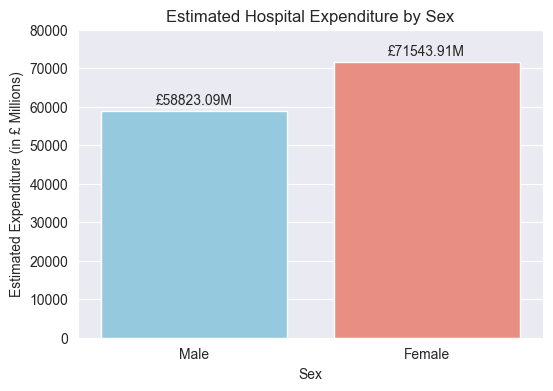

In [142]:
plt.figure(figsize=(6, 4))
estimated_exp_plot = sns.barplot(data=expenditure_by_gender_df, x='Gender', y='Estimated Expenditure', hue='Gender', palette=palette)
plt.title('Estimated Hospital Expenditure by Sex')
plt.xlabel('Sex')
plt.ylabel('Estimated Expenditure (in £ Millions)')
plt.ylim(0, 80000)
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
for container in estimated_exp_plot.containers:
    labels = [f"£{v.get_height():.2f}M" for v in container]
    estimated_exp_plot.bar_label(container, labels=labels, padding=3)
plt.show()

**Plot Summary:**

Using the total hospital expenditure from the UK Health Accounts 2024 data and the Hospital Admitted Patient Care 2023-24 Demographic data, total expenditure based on sex has been estimated.

- Total Hospital Expenditure (All Functions): £130,367,000,000.00
- Estimated Male Hospital Expenditure: £58,823,086,053.68
- Estimated Female Hospital Expenditure: £71,543,913,946.32

Care for women made up 55% of the Hospital Admitted Patient Care 2023-24 Demographic data, which is consistent with other areas of our data analysis.

#### Comparison to ONS population percentage

https://www.ons.gov.uk/aboutus/transparencyandgovernance/freedomofinformationfoi/populationoftheukbysex

According to the Population estimates for the UK, England, Wales, Scotland and Northern Ireland: mid-2021, released on 21 December 22 the total UK population was:

Total pop: 67,026,292
Females: 34,214,835
Males: 32,811,457

In [124]:
ons_population_data = {
    "Gender": ['Female', 'Male', 'Total'],
  "Count": [34214835, 32811457, 67026292]
}
ons_population_df = pd.DataFrame(ons_population_data)

ons_population_df["Percentage"] = (
    ons_population_df["Count"] / ons_population_df.loc[ons_population_df["Gender"] == "Total", "Count"].values[0]
)
display(ons_population_df)

,Gender,Count,Percentage
0,Female,34214835,0.510469
1,Male,32811457,0.489531
2,Total,67026292,1.000000


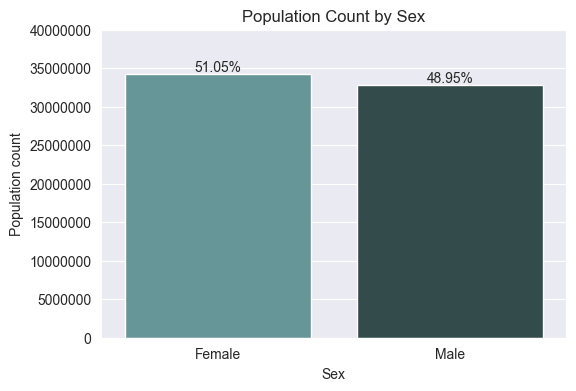

In [143]:
ons_population_df_gender = ons_population_df[ons_population_df["Gender"].isin(["Female", "Male"])].copy()

comparison_palette = {"Female": "cadetblue", "Male": "darkslategrey"}

plt.figure(figsize=(6, 4))
ons_population_plot = sns.barplot(data=ons_population_df_gender, x='Gender', y='Count', hue='Gender', palette=comparison_palette)
plt.title('Population Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Population count')
plt.ylim(0, 40000000)
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)

for i, container in enumerate(ons_population_plot.containers):
    current_percentage_label = [f"{ons_population_df_gender['Percentage'].iloc[i]:.2%}"]
    ons_population_plot.bar_label(
        container,
        labels=current_percentage_label,
    )
plt.show()

Heathcare spending and usage statistics for women outstrip the population split as of the 2021 census data.

In [126]:
# Hospital admitted patient care 2023-24 - Primary Diagnosis Summary table
diagnosis_summary_df = pd.read_csv('../data/clean//diagnosis_summary_clean.csv')

# Hospital admitted patient care 2023-24 - Primary Diagnosis 3 Char table
diagnosis_3_char_df = pd.read_csv('../data/clean/diagnosis_3_char_clean.csv')

display(diagnosis_summary_df.head())

,code,description,sex,diagnosis_count,category
0,A00-A09,Intestinal infectious diseases,Male,87268,Certain infectious and parasitic diseases (A00...
1,A15-A19,Tuberculosis,Male,3924,Certain infectious and parasitic diseases (A00...
2,A20-A28,Certain zoonotic bacterial diseases,Male,198,Certain infectious and parasitic diseases (A00...
3,A30-A49,Other bacterial diseases,Male,144404,Certain infectious and parasitic diseases (A00...
4,A50-A64,Infections with a predominantly sexual mode of...,Male,1388,Certain infectious and parasitic diseases (A00...


In [127]:
diagnosis_summary_wide = diagnosis_summary_df.pivot(index='description', columns='sex', values='diagnosis_count')
diagnosis_summary_wide['total'] = diagnosis_summary_wide.sum(axis=1)

top_10_diagnoses = diagnosis_summary_wide.sort_values(by=['total'], ascending=False).head(10)
display(top_10_diagnoses)

sex,Female,Male,total
description,,,
Disorders of lens (including cataracts),437026,308994,746020
Other diseases of intestines,380042,351026,731068
General symptoms & signs,373440,318562,692002
Influenza & pneumonia,313724,310456,624180
Other forms of heart disease,253225,328884,582109
Symptoms & signs inv. the digestive system & abdomen,368544,197018,565562
Arthropathies,333696,227662,561358
Health services in circumstances related to reproduction,316606,184215,500821
"Diseases of oesophagus, stomach & duodenum",254757,244242,498999


In [128]:
male_diagnoses_df = diagnosis_summary_df[diagnosis_summary_df['sex'] == 'Male'].copy()
total_male_diagnosis_count = male_diagnoses_df['diagnosis_count'].sum()
male_diagnoses_df['proportion'] = male_diagnoses_df['diagnosis_count'] / total_male_diagnosis_count

female_diagnoses_df = diagnosis_summary_df[diagnosis_summary_df['sex'] == 'Female'].copy()
total_female_diagnosis_count = female_diagnoses_df['diagnosis_count'].sum()
female_diagnoses_df['proportion'] = female_diagnoses_df['diagnosis_count'] / total_female_diagnosis_count

combined_proportions_df = pd.concat([male_diagnoses_df, female_diagnoses_df]).reset_index(drop=True)

display(combined_proportions_df.head())

,code,description,sex,diagnosis_count,category,proportion
0,A00-A09,Intestinal infectious diseases,Male,87268,Certain infectious and parasitic diseases (A00...,0.009081
1,A15-A19,Tuberculosis,Male,3924,Certain infectious and parasitic diseases (A00...,0.000408
2,A20-A28,Certain zoonotic bacterial diseases,Male,198,Certain infectious and parasitic diseases (A00...,0.000021
3,A30-A49,Other bacterial diseases,Male,144404,Certain infectious and parasitic diseases (A00...,0.015027
4,A50-A64,Infections with a predominantly sexual mode of...,Male,1388,Certain infectious and parasitic diseases (A00...,0.000144


In [130]:
average_cost_percentage_df = grouped_cost.groupby('BREAKDOWN_GROUP_1')['PERCENTAGE_COST'].mean().reset_index()
average_cost_percentage_df = average_cost_percentage_df.rename(columns={'BREAKDOWN_GROUP_1': 'Sex'})
display(average_cost_percentage_df)

,Sex,PERCENTAGE_COST
0,Female,0.549949
1,Male,0.450051


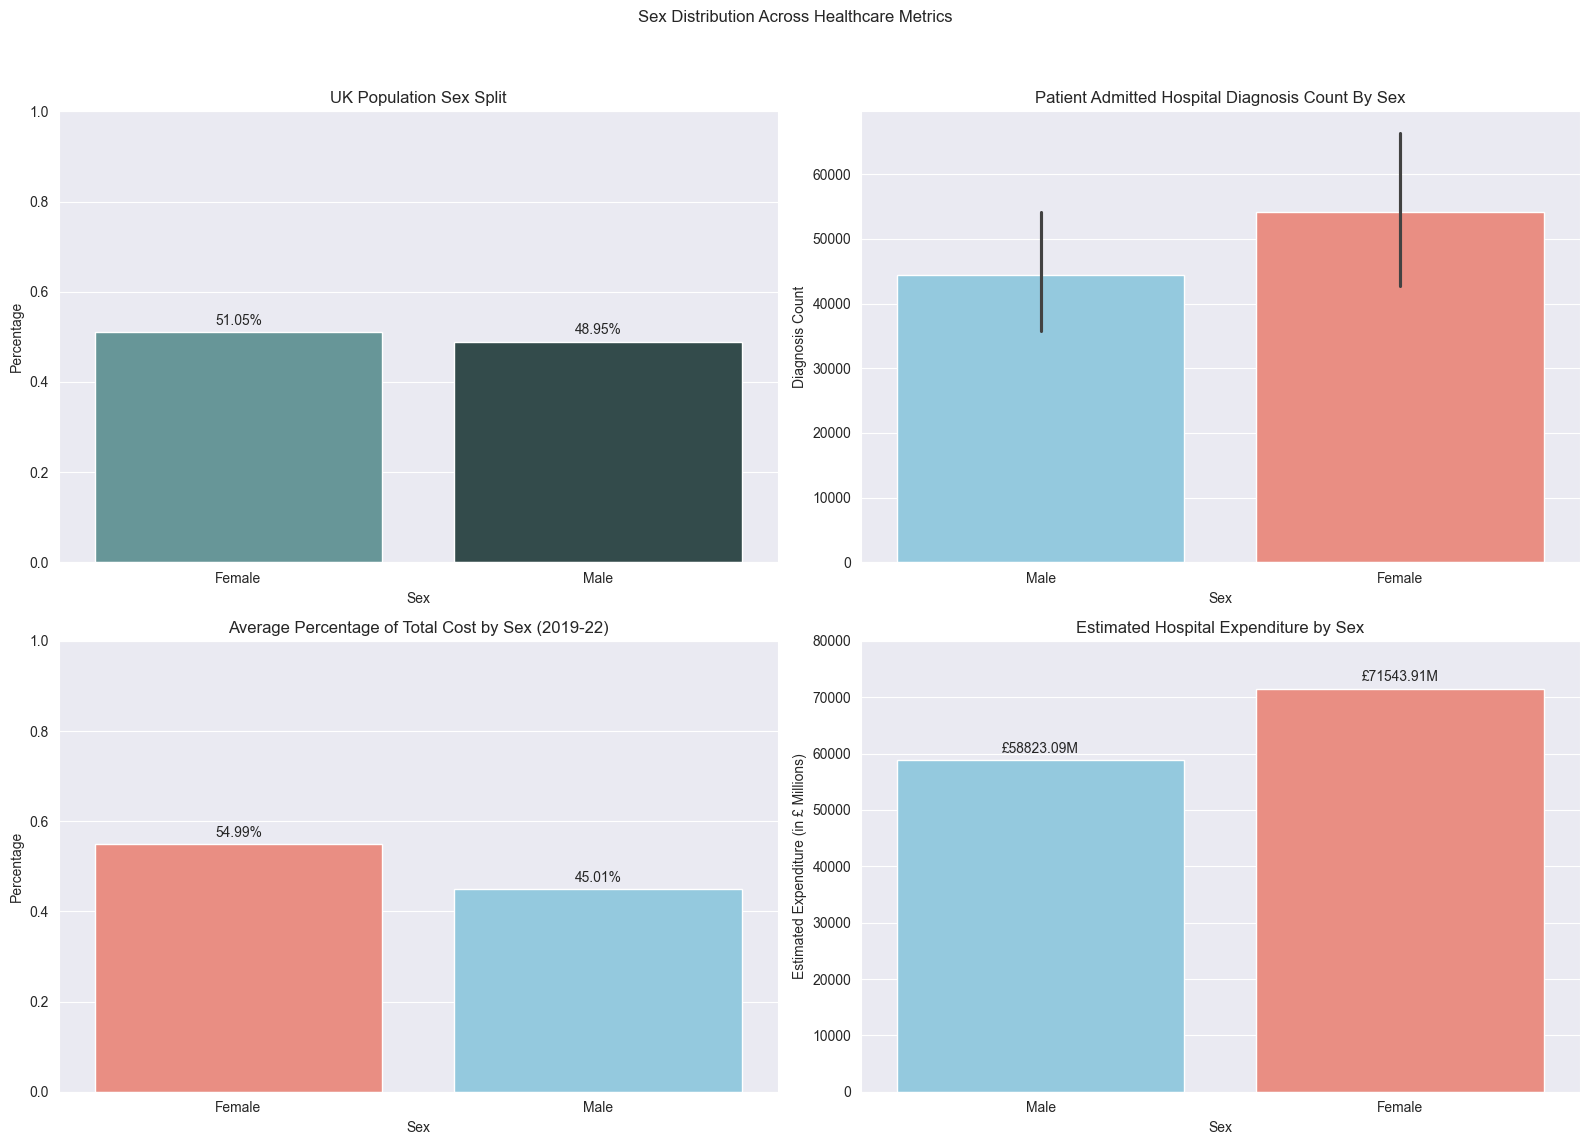

In [145]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sex Distribution Across Healthcare Metrics')

# Subplot 1: UK Population Gender Split
sns.barplot(ax=axes[0, 0], data=ons_population_df_gender, x='Gender', y='Percentage', hue='Gender', palette = comparison_palette, legend=False)
axes[0, 0].set_title('UK Population Sex Split')
axes[0, 0].set_xlabel('Sex')
axes[0, 0].set_ylabel('Percentage')
axes[0, 0].set_ylim(0, 1)
for container in axes[0, 0].containers:
    labels = [f"{v.get_height():.2%}" for v in container]
    axes[0, 0].bar_label(container, labels=labels, padding=3)

# Subplot 2: Hospital diagnosis count by gender
sns.barplot(ax=axes[0, 1], data=diagnosis_summary_df, x='sex', y='diagnosis_count', hue='sex', palette=palette, legend=False)
axes[0, 1].set_title('Patient Admitted Hospital Diagnosis Count By Sex')
axes[0, 1].set_xlabel('Sex')
axes[0, 1].set_ylabel('Diagnosis Count')

# Subplot 3: Average grouped Cost by Gender
sns.barplot(ax=axes[1, 0], data=average_cost_percentage_df, x='Sex', y='PERCENTAGE_COST', hue='Sex', palette=palette, legend=False)
axes[1, 0].set_title('Average Percentage of Total Cost by Sex (2019-22)')
axes[1, 0].set_xlabel('Sex')
axes[1, 0].set_ylabel('Percentage')
axes[1,0].set_ylim(0,1)
for container in axes[1,0].containers:
    labels = [f"{v.get_height():.2%}" for v in container]
    axes[1,0].bar_label(container, labels=labels, padding=3)

# Subplot 4: Estimated hospital expenditure by gender
sns.barplot(ax=axes[1, 1], data=expenditure_by_gender_df, x='Gender', y='Estimated Expenditure', hue='Gender', palette=palette)
axes[1, 1].set_title('Estimated Hospital Expenditure by Sex')
axes[1, 1].set_xlabel('Sex')
axes[1, 1].set_ylabel('Estimated Expenditure (in £ Millions)')
plt.ylim(0, 80000)
plt.gcf().axes[1].yaxis.get_major_formatter().set_scientific(False)
for container in axes[1, 1].containers:
    labels = [f"£{v.get_height():.2f}M" for v in container]
    axes[1, 1].bar_label(container, labels=labels, padding=3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Summary of Sex and Spending Distributions Across Healthcare Metrics**

UK Population Gender Split:
- The UK population 2021 data shows a minimal difference between gender, with the plit being approximately 51% women, 49% men.

Estimated Hospital Expenditure by Sex, Average Percentage of Total Cost by Sex (2019-22) and Percentage of Diagnosis Counts by Sex:
- These datasets show a consistent trend of a 55%/45% split between women and men. This suggests that women use hospital services more, or incur higher costs within the hospital system, compared to their proportion in the general population.

This analysis highlights a clear trend where women, despite being a smaller majority in the general population, consume a larger share of healthcare resources and services.